# 4주차 · 발사체 시스템 설계와 운용

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/gabraxas/LVs-and-Policy/blob/main/lecture/week04/week04.ipynb)

> 이 노트북은 GitHub에 저장되고 Colab에서 실행됩니다. 위 배지를 눌러 Colab에서 열거나, 아래 첫 코드 셀부터 순서대로 실행하세요.

In [ ]:
# ▶ 실행 전 준비 — 이 셀을 먼저 실행하세요 (약 10~20초 소요)
!pip install -q ipywidgets
!apt-get -qq install -y fonts-nanum > /dev/null 2>&1

import urllib.request
urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/gabraxas/LVs-and-Policy/main/lecture/_shared/course_interactive.py",
    "course_interactive.py")

from course_interactive import *
setup_korean_font()
print("준비 완료 — 아래 셀들을 순서대로 실행하며 강의를 진행하세요.")


# 4주차 · 발사체 시스템 설계와 운용

### Launch Vehicle Systems Design & Operations — 엔진을 기체에 얹고, 궤도까지 안전하게 올려 보내는 일

> **우주수송정책과 발사체 기술** — Week 04
> 참고: Karabeyoglu, AA284a *Advanced Rocket Propulsion* — Lecture 7: Launch Trajectories, Stanford University · Wertz & Larson, *Space Mission Analysis and Design (SMAD)*
> 서술 구조 참고: [ERAU, *Introduction to Aerospace Flight Vehicles* — "Rockets & Launch Vehicle Performance"](https://eaglepubs.erau.edu/introductiontoaerospaceflightvehicles/chapter/rocket-performance/)

---

## 서론

- 지금까지는 부분을 봤음 (2주차 궤도역학·로켓방정식, 3주차 추진 시스템)
- 이번 주: 그 부분들이 **하나의 시스템으로 묶일 때 생기는 제약과 절충**을 다룸
- 각 부는 앞부분의 결과를 제약조건으로 받음 — 구조가 궤적을 제약하고, 궤적이 제어를 제약하며, 제어가 운용을 제약

| 파트 | 내용 |
|---|---|
| PART I | 구조와 경량화 — 하중·탱크 구조·재료, 구조질량비의 지배력 |
| PART II | 상승궤적 설계 — 중력선회·Max-Q, 제약 속의 최적화 |
| PART III | 항법·유도·제어 — GNC 삼각형, 연성 진동 문제 |
| PART IV | 발사장과 안전 — 입지 조건·비행종단, 나로우주센터의 제약 |
| PART V | 실패에서 배우기 — 4대 사례 유형학, 개발 방식의 선택 |
| PART VI | 미션 분석 심화 — 궤도 6요소·SSO·Footprint·궤적손실·최적제어·GNC 개관 |
| PART VII | 하중해석과 예비구조설계 — 하중 종류·하중사이클·설계기준·등가하중·Isogrid 사이징 |

> **오늘의 한 문장**: 발사체 설계에서 어려운 것은 각 부분을 잘 만드는 일이 아니라, 서로 충돌하는 요구조건들 사이에서 전체 최적점을 찾는 일이다.

## 학습 목표

- [ ] **구조 설계의 제약을 설명한다** — 발사체가 견디는 하중의 종류와 발생 시점, 탱크 구조 방식과 재료 선택의 논리, 구조질량 1%가 탑재량에 미치는 영향
- [ ] **상승궤적이 왜 그 모양인지 안다** — 수직상승 → 중력선회 → 진공궤적 → 투입, 중력손실 최소화와 Qmax·가속도 제약의 충돌, 코스팅·도그레그·에어론치의 목적
- [ ] **GNC의 역할 분담을 구분한다** — 항법·유도·제어가 각각 답하는 질문, 관성항법의 원리와 한계, 폐루프 유도, 슬로싱·굽힘모드·POGO 같은 연성 문제
- [ ] **운용과 안전을 정책으로 연결한다** — 발사장 입지 조건과 나로우주센터의 제약, 비행종단시스템과 낙하예상구역, 실패 사례의 유형학과 개발 방식의 선택
- [ ] **미션을 궤도요소로 정의하고 설계에 반영한다** — 케플러 궤도 6요소, 태양동기궤도(SSO)의 원리와 활용, 위성 Footprint 기하학, 궤적 손실의 미션분석적 재해석
- [ ] **예비 구조설계의 흐름을 계산한다** — 하중의 종류와 통계적 정의(99/90 기준), 안전계수와 등가하중 산출, Isogrid 구조 사이징의 3대 파손모드 검증

### 발사체는 무엇으로 이루어져 있는가

- 추진은 전체의 한 조각 — 나머지 조각들이 추진 성능을 실제 탑재량으로 바꿔줌

| 서브시스템 | 구성 | 다루는 곳 |
|---|---|---|
| 추진계 | 엔진·터보펌프·추진제 공급·가압계 | 3주차 |
| 구조계 | 탱크·단간부·페어링·분리장치 | Part I |
| 유도항법제어 | 관성항법장치·비행 컴퓨터·구동기 | Part III |
| 전자·전력계 | 배터리·배선·텔레메트리·안전장치 | Part III·IV |
| 지상계 | 발사대·추진제 공급설비·관제·추적 | Part IV |

**시스템 차원의 '예산' — 무엇을 배분하는가, 왜 서로 얽히는가**

- **질량 예산**: 구조·추진·탑재의 질량이 서로 경쟁 — 구조 1 kg을 줄이면 탑재 1 kg이 늘어남(상단 기준)
- **하중 예산**: 각 서브시스템이 견뎌야 할 하중을 배분 — 궤적 설계가 하중을 만들고, 하중이 구조 질량을 만듦
- **전력·열 예산**: 비행 시간 동안의 전력과 열을 배분 — 비행 시간이 길수록 배터리·단열이 무거워짐
- **신뢰도 예산**: 목표 성공률을 부품 단위로 분배 — 부품 수가 늘면 각 부품에 더 높은 신뢰도가 요구됨

> **핵심 개념**: 발사체 설계는 이 '예산'들을 동시에 만족시키는 해를 찾는 일이다. 한 예산을 넉넉히 잡으면 다른 예산이 반드시 부족해진다.

---

## PART I · 구조와 경량화

### 1.1 왜 구조 엔지니어가 1 kg 때문에 싸우는가

- 2주차 로켓방정식에서 질량비는 지수 안에 있었음 → 구조 질량은 그 지수를 직접 갉아먹는 항

$$
\varepsilon = \frac{m_{구조}}{m_{구조} + m_{추진제}} \quad (\text{구조질량비 — 낮을수록 좋지만, 낮출수록 안전여유가 사라진다})
$$

- **감각을 위한 숫자**: 잘 만든 액체 발사체 단의 ε는 0.05\~0.09. 추진제 가득 찬 탱크 무게 중 구조는 5~9%뿐 — 음료 캔보다 얇은 벽으로 이 일을 함

| 변화 | 탑재량 영향(경향) | 이유 |
|---|---|---|
| 상단(2단) 구조 1 kg 증가 | 탑재량 약 1 kg 감소 | 상단 질량은 탑재량과 거의 1:1로 경쟁 |
| 1단 구조 1 kg 증가 | 탑재량 약 0.05~0.1 kg 감소 | 1단은 상단 분리 전에 버려지므로 영향이 훨씬 작음 |
| 상단 Isp 1 s 증가 | 탑재량 수 kg~수십 kg 증가 | 그래서 상단은 성능, 1단은 비용·추력이 우선 |

- **그래서 생기는 일**
  - 안전계수(safety factor)를 1.25~1.4까지 낮춰 잡음 — 항공기(1.5)보다도 공격적
  - 1회용 구조는 '한 번만 견디면 된다'는 전제로 설계됨
  - 재사용 구조는 이 전제를 버려야 하므로 더 무거워짐
- **재사용의 구조적 대가**
  - 착륙 다리·격자날개·재진입 보호재가 모두 순수한 추가 질량
  - 회수용 추진제까지 남겨야 하므로 유효 탑재량이 30~40% 감소
  - 5주차 재사용 경제성은 이 손실을 재비행 횟수로 상쇄하는 계산이었음

### <참고> 자동차 vs 로켓의 구조비 비교


| 구분 | 대상 | 총중량 | 구조부문 중량 | 추진제/연료 중량 | 구조비 (구조/총중량) |
|---|---|---|---|---|---|
| **로켓** | Falcon 9 1단 | 약 433 t | 약 25~30 t | 약 400 t | **약 5~7 %** |
| | Saturn V 1단(S-IC) | 약 2,300 t | 약 130 t | 약 2,170 t | **약 5~6 %** |
| | Space Shuttle 외부연료탱크(ET) | 약 760 t | 약 30 t | 약 730 t | **약 4 %** |
| | Atlas V 1단 | 약 306 t | 약 21 t | 약 285 t | **약 7~8 %** |
| | 일반적 상단(2단) 로켓 | — | — | — | **약 8~12 %** |
| **자동차** | 일반 중형 세단 (내연기관) | 약 1,530 kg | 약 1,500 kg (공차중량) | 약 30 kg (연료 40 L) | **약 97~98 %** |
| | 소형 해치백 | 약 1,150 kg | 약 1,120 kg | 약 30 kg (연료 40 L) | **약 97 %** |
| | 대형 SUV | 약 2,300 kg | 약 2,220 kg | 약 80 kg (연료 100 L) | **약 96~97 %** |
| | 전기차(배터리 포함, 참고용) | 약 2,000 kg | 약 2,000 kg (배터리가 곧 구조체 일부) | 해당 없음(개념 다름) | **~100 %에 근접** |

---

## 핵심 비교

| 지표 | 로켓 | 자동차 |
|---|---|---|
| 구조비 (ε) | **약 5~10 %** | **약 95~98 %** |
| 추진제(연료) 비중 | **약 90~95 %** | **약 2~5 %** |
| 설계 철학 | "무게를 실어 나르는 그릇"이 최소화되도록 설계 — 구조는 최대한 가볍게, 대부분의 질량을 추진제로 채움 | 구조(차체·엔진·서스펜션 등)가 곧 상품 가치이자 성능의 원천 — 연료는 부수적 소모품 |
| 성능에 미치는 영향 | 구조비가 낮을수록 로켓방정식(Tsiolkovsky)상 $\Delta V$와 페이로드 비율이 커짐 — 구조 경량화가 곧 성능 | 연료 소모는 항속거리·연비에만 영향 — 구조 경량화는 성능보다는 연비·안전·비용에 영향 |


## 1.2 우주발사체의 구성요소들 : Part Breakdown Structure
### 1.2.1 전체 스택 구조 (Top-Down)
<div style="display: flex; justify-content: center; align-items: center; gap: 10px;" align="center">
  <img src="https://raw.githubusercontent.com/gabraxas/LVs-and-Policy/main/lecture/week04/images/Ares_I.png" height="480">
</div>



```
Ares I (전체 스택, GLOM ≈ 927 t / 2,044K lbm, 전장 ≈ 99 m/325 ft)
│
├── 1. Launch Abort System (LAS) — Orion 최상단, 비상탈출용
│
├── 2. Orion (CEV, 승무원 우주선)
│   ├── Crew Module (CM)
│   ├── Service Module (SM) — Encapsulated Service Module Panels
│   └── Spacecraft Adapter
│
├── 3. Upper Stage Engine — J-2X (LOX/LH2, Pratt & Whitney Rocketdyne)
│
├── 4. Upper Stage (US, 상단) — 137.1 t LOX/LH2 추진제, 직경 5.5 m(18 ft)
│   ├── Instrument Unit (IU) — Orion과의 구조/전기 인터페이스, 주 항법·유도 avionics
│   ├── Forward Skirt — IU와 LH2 탱크 사이 하중 전달
│   ├── LH2 Tank (+ Common Bulkhead) — 2195 Al-Li 합금, 마찰교반용접(FSW)
│   ├── Intertank
│   ├── LOX Tank — 2195 Al-Li 합금
│   ├── Thrust Cone / Aft Skirt / Thrust Structure — 상단-엔진 구조 인터페이스
│   ├── System Tunnel — 배선/배관 통로
│   ├── Interstage — 1단과의 구조적 연결부
│   ├── Main Propulsion System (MPS), 가압/공압계통
│   ├── Thrust Vector Control (TVC)
│   ├── Reaction Control System (RoCS) — 상단 자세제어
│   └── Avionics (IU, Aft Skirt, Interstage 등에 분산 탑재)
│
└── 5. First Stage (1단, 5-segment RSRMV, 고체) — 추력 350만 lbf 이상
    ├── 고체로켓모터(SRM) — Shuttle RSRM 기반, 5세그먼트, PBAN 추진제, 신규 노즐
    ├── Forward Structures (신규 개발)
    │   ├── Forward Skirt
    │   ├── Forward Skirt Extension (FSE)
    │   ├── Aeroshell — 낙하산 회수계통 수납
    │   └── Frustum — 상단과의 인터페이스, 직경 전이부(146"→216")
    ├── Aft Skirt (Shuttle 유산 하드웨어) — TVC 계통 포함, 발사대 지지
    ├── Recovery System — Drogue + Main 낙하산 3개(직경 150 ft), Booster Deceleration/Tumble Motors
    └── First Stage Avionics / Roll Control System (RoCS) — 1단 롤 제어
```



### Falcon 9의 PBS와 MBS(Mass Breakdown Structure)
<div style="display: flex; justify-content: center; align-items: center; gap: 10px;" align="center">
  <img src="https://raw.githubusercontent.com/gabraxas/LVs-and-Policy/main/lecture/week04/images/f9.jfif" height="480">
</div>



```
Falcon 9 (2단형, 부분 재사용)
│
├── 1. Payload Fairing (페어링)
│   ├── 복합재(탄소섬유) 쉘 2쪽(halves)
│   ├── 분리기구(pneumatic actuator) + 래치 14개
│   └── 파라포일 낙하산(회수용, 재사용)
│
├── 2. 2단 (Second Stage)
│   ├── LOX 탱크 (모노코크 구조)
│   ├── RP-1 연료탱크 (스킨-스트링거 구조)
│   ├── Merlin Vacuum(MVac) 엔진 ×1 — 짐벌 구동
│   ├── 질소가스 냉가스 추력기(RCS) — 자세제어/롤제어
│   └── 항전/배관계통
│
├── 3. Interstage (단간연결부)
│   ├── 탄소섬유 복합재 구조
│   ├── Pneumatic Pusher(공압식 단분리 장치)
│   └── Grid Fins ×4 (재진입 자세제어, 1단 하강 시 사용)
│
├── 4. 1단 (First Stage, 재사용)
│   ├── LOX 탱크 (모노코크, Al-Li 합금)
│   ├── RP-1 연료탱크 (스킨-스트링거, Al-Li 합금)
│   ├── Octaweb 구조 — Merlin 1D 엔진 9기 장착 트러스
│   ├── Merlin 1D 엔진 ×9 (외곽 8기 + 중앙 1기)
│   ├── 착륙다리(Landing Legs) ×4 — 탄소섬유/알루미늄 허니콤, 착륙 직전 전개
│   ├── 콜드가스(질소) 추력기 — 재진입 플립 기동 및 자세제어
│   └── 비행종료시스템(FTS)
│
└── (페이로드) — 위성 어댑터 또는 Dragon 캡슐로 대체 가능

```

## 1.3 구조비를 줄이기 위해서는 어디를 열일 해야하는가?

---

## 1.3.1 MBS (Mass Breakdown Structure — 상위 수준)

| 구성요소 | 건조질량(구조) | 추진제 질량 | 비고 |
|---|---|---|---|
| **1단 (First Stage)** | 약 22,200~25,600 kg | 약 395,700~411,000 kg | 구조비 ε ≈ 5~6% |
| **2단 (Second Stage)** | 약 3,900 kg | 약 92,670 kg | 구조비 ε ≈ 4% |
| **페이로드 페어링** | 약 1,750~1,900 kg | — | 2쪽 합산, 재사용형 |
| **전체(GLOM)** | — | — | 약 549,054 kg |

---

## 1.3.2 MBS (서브시스템 수준 상세)

### 1단 (총 건조질량 25,600 kg)

| 서브시스템 | 질량 | 비율 |
|---|---|---|
| 탱크·구조 (LOX/RP-1 탱크, Octaweb, 스커트) | 16,500 kg | 64.5% |
| 엔진 (Merlin 1D ×9) | 4,230 kg | 16.5% |
| 착륙다리 (×4, 탄소섬유/Al 허니콤) | 2,100 kg | 8.2% |
| 가압/가스계통 (헬륨 COPV, 배관) | 1,200 kg | 4.7% |
| TVC 액추에이터/유압계통 | 700 kg | 2.7% |
| 항전 (avionics, FTS) | 500 kg | 2.0% |
| 기타 (배선, 밸브, 단열재) | 370 kg | 1.4% |

### 2단 (총 건조질량 3,900 kg)

| 서브시스템 | 질량 | 비율 |
|---|---|---|
| 탱크·구조 (LOX/RP-1 탱크) | 2,700 kg | 69.2% |
| 엔진 (MVac ×1) | 600 kg | 15.4% |
| 항전 (avionics) | 250 kg | 6.4% |
| RCS (질소 콜드가스 추력기) | 200 kg | 5.1% |
| 기타 (배선, 밸브) | 150 kg | 3.8% |

---

## 1.3.3 추정 방법론

- **엔진 질량**: Merlin 1D 공개 건조중량(~470 kg) × 9기 = 4,230 kg. MVac은 진공 노즐이 커서 더 무거운 편이므로 ~600 kg으로 가정.
- **착륙다리**: 4개 합산 공개 추정치(~2,100 kg) 반영 — 1단에만 해당(재사용을 위한 추가 중량).
- **탱크/구조**: 전체 건조질량에서 엔진·다리·가스계통 등을 뺀 잔여값으로 역산 — 일반적으로 로켓 단의 건조질량 중 가장 큰 비중(60~70%)을 차지한다는 업계 경험칙과 일치.
- **가압/가스·TVC·항전·기타**: 일반 발사체 서브시스템 질량 배분 비율(가스계통 4~7%, TVC 2\~5%, 항전 2\~5%)을 적용.

---

## 1.3.4 핵심 관찰

$$
\varepsilon_{1단} = \frac{25{,}600}{25{,}600+395{,}700} \approx 6\%, \qquad
\varepsilon_{2단} = \frac{3{,}900}{3{,}900+92{,}670} \approx 4\%
$$

- 1단은 **재사용을 위한 착륙다리(8.2%)라는 추가 "세금"**이 붙어 있음에도, 탱크/구조 비중이 여전히 압도적(64.5%)임.
   - 이는 초경량 Al-Li 탱크 설계 덕분
- 2단은 착륙다리·그리드핀 등 회수 관련 중량이 전혀 없어 탱크/구조 비중이 오히려 더 높게(69.2%) 나타남
   — 회수 장비가 빠진 "순수 발사체" 구조에 가깝움
- 엔진 질량 비중(15~17%)은 두 단이 비슷한데, 이는 Merlin 계열 엔진이 1단·2단 모두 동일한 터보펌프 사이클 기반이라 무게 대비 추력비가 유사하기 때문

> **참고**: 위 서브시스템 수준 수치는 SpaceX 공식 발표가 아닌 공개된 부품 데이터와 일반적인 발사체 설계 관행을 바탕으로 한 공학적 추정치임


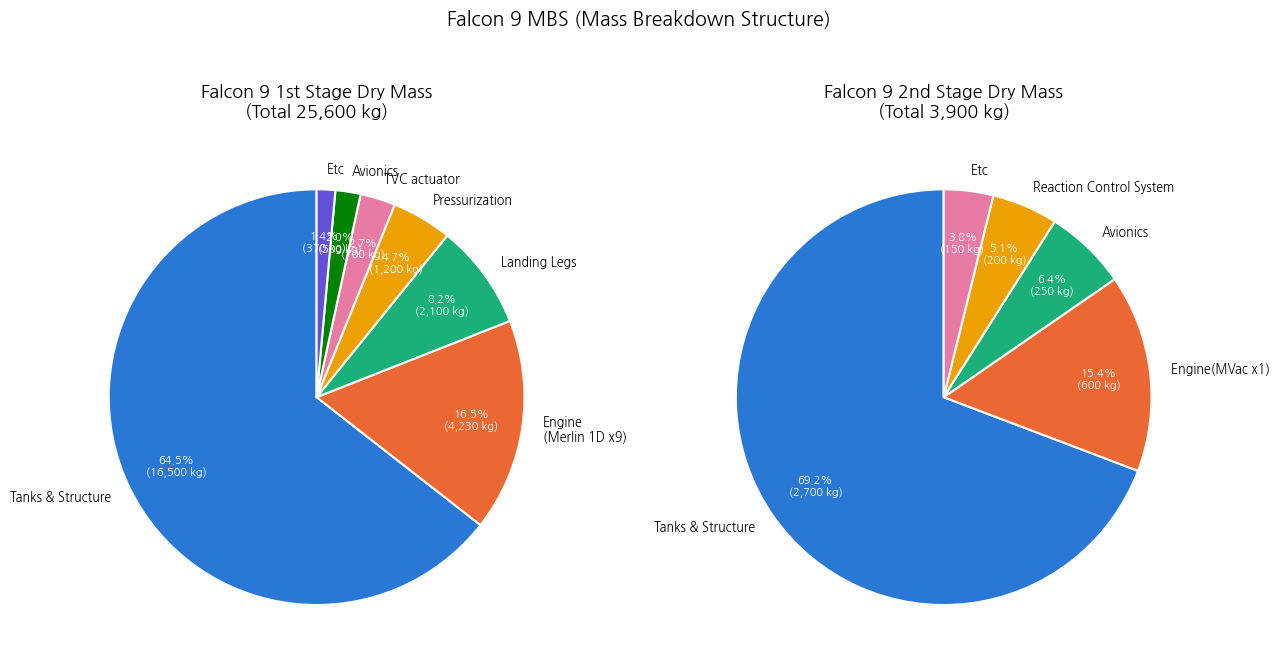

In [6]:
"""
Falcon 9 MBS (Mass Breakdown Structure) 파이차트
- 1단(First Stage)과 2단(Second Stage)의 건조질량(구조) 서브시스템별 구성비를 시각화
- 수치는 공개 자료(SpaceX 스펙시트, FAA 신고자료) 및 공학적 추정치를 종합한 근사치
"""

import matplotlib.pyplot as plt

# 셀 1: 나눔고딕 설치 (최초 1회만 필요)
!apt-get -y install fonts-nanum -qq > /dev/null 2>&1
import matplotlib.font_manager as fm
fm.fontManager.addfont("/usr/share/fonts/truetype/nanum/NanumGothic.ttf")

# 경고 무시
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# ------------------------------------------------------------------
# 데이터: 서브시스템별 건조질량 (kg)
# ------------------------------------------------------------------
stage1_labels = [
    "Tanks & Structure",
    "Engine\n(Merlin 1D x9)",
    "Landing Legs",
    "Pressurization",
    "TVC actuator",
    "Avionics",
    "Etc",
]
stage1_masses = [16500, 4230, 2100, 1200, 700, 500, 370]  # 합계 25,600 kg

stage2_labels = [
    "Tanks & Structure",
    "Engine(MVac x1)",
    "Avionics",
    "Reaction Control System",
    "Etc",
]
stage2_masses = [2700, 600, 250, 200, 150]  # 합계 3,900 kg

# ------------------------------------------------------------------
# 색상 팔레트 (카테고리별 구분)
# ------------------------------------------------------------------
colors = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#6250d6"]

# ------------------------------------------------------------------
# 한글 폰트 설정 (환경에 나눔고딕 등이 있으면 자동 사용, 없으면 기본 폰트로 대체)
# ------------------------------------------------------------------
plt.rcParams["axes.unicode_minus"] = False
for font_name in ["NanumGothic", "Malgun Gothic", "AppleGothic"]:
    if font_name in [f.name for f in plt.matplotlib.font_manager.fontManager.ttflist]:
        plt.rcParams["font.family"] = font_name
        break

# ------------------------------------------------------------------
# 파이차트 그리기
# ------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 7))

def draw_pie(ax, labels, masses, colors, title, total_label):
    total = sum(masses)
    wedges, texts, autotexts = ax.pie(
        masses,
        labels=labels,
        colors=colors[: len(masses)],
        autopct=lambda p: f"{p:.1f}%\n({p * total / 100:,.0f} kg)",
        startangle=90,
        pctdistance=0.75,
        textprops={"fontsize": 9},
        wedgeprops={"edgecolor": "white", "linewidth": 1.5},
    )
    for autotext in autotexts:
        autotext.set_color("white")
        autotext.set_fontsize(8)
        autotext.set_fontweight("bold")
    ax.set_title(f"{title}\n(Total {total_label})", fontsize=13, fontweight="bold", pad=15)

draw_pie(axes[0], stage1_labels, stage1_masses, colors,
         "Falcon 9 1st Stage Dry Mass", "25,600 kg")
draw_pie(axes[1], stage2_labels, stage2_masses, colors,
         "Falcon 9 2nd Stage Dry Mass", "3,900 kg")

fig.suptitle("Falcon 9 MBS (Mass Breakdown Structure)",
             fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()

# ------------------------------------------------------------------
# 저장 및 출력
# ------------------------------------------------------------------
fig.savefig("falcon9_mbs_piechart.png", dpi=200, bbox_inches="tight")
plt.show()

#2 발사체가 견뎌야하는 하중



## 2.1 발사체가 견디는 하중 — 언제, 어떤 힘이 오는가

- 구조 설계는 '가장 센 힘'이 아니라 **'언제 어떤 조합으로 오는가'**의 문제
- 최대 하중은 대개 비행 초반 90초 안에 몰려 있음

| 국면 | 시점 | 지배 하중 | 설계·운용상의 대응 |
|---|---|---|---|
| 지상 대기·이송 | T−수시간 | 자중, 바람에 의한 굽힘, 수송 진동 | 빈 기체가 오히려 취약 → 탱크를 가압해 세워 둠 |
| 이륙·상승 초기 | T+0~40s | 엔진 추력에 의한 축압축, 음향하중(140dB↑) | 발사대 화염유도로와 살수(음향 억제) |
| 최대 동압(Max-Q) | T+60~80s | 동압 30~35kPa + 받음각에 의한 굽힘 | 구조 하중이 가장 가혹한 구간 — 스로틀 감소 |
| 연소 종료 직전 | MECO 직전 | 기체가 가벼워져 축가속도 최대(3~4g) | 탑재체 보호를 위해 추력을 낮추는 경우 많음 |
| 단분리·페어링 분리 | 각 이벤트 | 충격(pyroshock), 순간 비대칭 하중 | 충격이 전자장비에 전달되지 않도록 절연 설계 |

**Max-Q — 왜 여기가 최악인가**

$$
q = \tfrac{1}{2}\rho V^2
$$

- 속도는 계속 커지고 밀도는 계속 작아짐 → 두 곡선의 곱이 최대가 되는 지점이 Max-Q
- 이때 기체가 바람에 조금만 기울어도 옆방향 굽힘이 급증

In [ ]:
# 01-max-q-throttle-bucket.png 대신 인터랙티브 위젯으로 대체됨
max_q_explorer()

- **스로틀 버킷(throttle bucket)**
  - Max-Q 직전에 엔진 추력을 의도적으로 낮췄다가 통과 후 다시 올림
  - 성능(중력손실)을 조금 희생해 구조 하중을 낮추는 거래
  - 구조를 두껍게 하는 대신 궤적으로 하중을 관리하는 대표적 예 — Part II와 직결

# 2.2 탱크를 어떻게 만들 것인가 — 네 가지 계보

- 발사체 부피의 대부분은 추진제 탱크 → 탱크를 가볍게 만드는 방식이 곧 발사체의 성격을 결정

| 방식 | 원리 | 장점 | 단점 |
|---|---|---|---|
| 스킨-스트링거 | 얇은 외피에 세로 보강재(스트링거)와 원형 프레임을 붙임(항공기 동체와 같은 사고방식) | 가장 보편적·제작 노하우 축적 용이 | 부품 수와 리벳·용접 지점이 많음 |
| 등격자(Isogrid) | 두꺼운 판을 삼각 격자만 남기고 깎아냄(보강재와 외피가 한 덩어리) | 가볍고 강함·접합부 없음 | 가공 시간이 길고 재료 낭비가 큼 |
| 공통격벽 | 연료·산화제 탱크 사이 격벽을 하나로 공유해 기체 길이를 줄임 | 길이·질량 동시 절감 | 격벽 양쪽의 온도차 단열이 난제 |
| 압력안정형(풍선탱크) | 얇은 외피를 내부 압력으로 팽팽하게 유지해 형상을 잡음(보강재 거의 없음) | 구조질량비 극한까지 절감 | 가압 없이는 자립 불가 — 지상 취급이 까다로움 |

> **읽는 법**: 아래로 갈수록 구조는 가벼워지지만 취급은 까다로워진다. 다빈도 발사에서는 '지상에서 다루기 쉬운가'가 구조질량비만큼 중요한 기준이 된다.

# 2.3 재료 선택 — 가벼운 것이 항상 정답은 아니다

- 비강도만 보면 복합재가 압도적 → 그런데 현장의 선택은 그렇게 단순하지 않음

| 재료 | 강점 | 약점 | 주요 적용 |
|---|---|---|---|
| 알루미늄 합금 | 가공·용접 노하우 최다, 저온 강도 유지 | 비강도가 최고는 아님 | 다수 발사체의 표준 |
| 알루미늄-리튬(Al-Li) | 알루미늄 대비 밀도 낮고 강성 높음 | 가격이 비싸고 가공 까다로움 | STS 외부탱크, Falcon 9 |
| 탄소섬유 복합재 | 비강도 최고·페어링·단간부에 유리 | 극저온 추진제 탱크는 미세균열·투과 문제 | 페어링·고체 케이스 |
| 스테인리스강 | 고온 강도 우수·저렴·야외 용접 가능 | 밀도가 높아 무거움 | Starship — 재진입 발열을 재료로 버티는 전략 |

- **스테인리스강의 역설**
  - 밀도로만 보면 알루미늄의 약 3배 — 명백히 불리한 선택
  - 그러나 재진입 온도에서도 강도를 유지 → 열보호재를 크게 줄일 수 있음
  - 야외 용접·제작 가능 → 대형 구조물의 제조 단가·공기가 급감
  - 재료 선택이 '가장 가벼운 것'이 아니라 **'전체 시스템에서 가장 싼 것'**으로 이동한 사례
- **복합재가 탱크에서 고전하는 이유**
  - 극저온에서 수지·섬유의 수축률이 달라 미세균열 발생 → 액체수소가 새어 나감
  - 손상 여부를 눈으로 확인 불가 → 비파괴검사 비용이 큼
  - 그래서 압력을 덜 받는 페어링·단간부·고체모터 케이스에 먼저 자리 잡음
  - 다만 최근 극저온 복합재 탱크의 실용화 시도가 다시 활발

### 1.5 페어링과 분리장치 — 가장 단순해 보이는 곳이 가장 자주 실패한다

- 추력도, 방향도 잡지 않는 부품이지만 발사 실패 원인 목록에서는 상위권

- **페어링의 임무**
  - 대기권 통과 중 탑재체를 공력·음향·열로부터 보호
  - 대기가 희박해지는 시점(고도 100 km 내외)에 분리
  - 분리가 이를수록 질량 이득 — 그러나 탑재체 가열 위험
- **왜 어려운가**
  - 단 한 번, 진공에서, 되돌릴 수 없이 작동해야 함
  - 지상에서 완벽한 환경 재현 불가능
  - 두 짝이 동시에 떨어져야 하며, 한쪽만 남으면 임무 실패

> **국내 사례**: 나로호 1차 발사(2009)에서 페어링 한쪽이 분리되지 않아 위성이 궤도에 오르지 못했다. 추진계는 정상 작동했음에도 임무는 실패했다.

| 분리 이벤트 | 대표 방식 | 설계상의 관건 |
|---|---|---|
| 단분리 | 폭발볼트·절단코드·클램프밴드 | 충격이 크지만 확실·잔여추력에 의한 재접촉 위험 |
| 페어링 분리 | 세로 절단 후 힌지 회전 또는 밀어내기 | 두 짝의 동시성 확보가 핵심 |
| 탑재체 분리 | 스프링 방출·저충격 분리장치 | 회전(텀블링) 없이 떠나보내야 함 |
| 재점화 대비 | 얼리지 모터로 추진제를 탱크 바닥에 안착 | 무추력 구간 후 재점화 실패를 막는 장치 |

> **공통점**: 이들은 모두 '한 번만, 되돌릴 수 없이' 작동하는 이벤트다. 지상 시험으로 확인할 수 있는 범위가 좁아 설계 여유와 이중화가 유일한 방어책이 된다.

---

## PART II · 상승궤적 설계

### 2.1 상승궤적은 왜 이런 모양인가 — 네 국면

- 수직으로 쏘아 올려 옆으로 눕힌다 — 이 단순한 문장 안에 발사체 설계의 절반이 들어 있음

In [ ]:
# 02-ascent-trajectory-phases.png 대신 인터랙티브 위젯으로 대체됨
ascent_trajectory_explorer()

1. **수직 상승**: 대기의 조밀한 층을 최단거리로 빠져나감. 궤적각이 커서 중력손실이 크지만, 동압·공력하중을 줄이기 위해 감수
2. **피치오버·중력선회**: 약간 기울여 준 뒤에는 중력이 알아서 기체를 눕힘. 받음각을 0에 가깝게 유지해 옆방향 굽힘하중을 없앰
3. **진공 궤적**: 대기를 벗어나면 항력 제약이 사라짐. 이제부터는 수평 방향 가속에 집중해 궤도속도를 만듦
4. **궤도 투입**: 목표 고도에서 궤적각 0°, 궤도속도 도달. 많은 경우 주차궤도에 넣은 뒤 원지점에서 다시 점화해 원궤도화

> **중력선회(gravity turn)의 묘미**: 초기에 살짝 기울여 주면, 이후에는 조종 없이도 중력이 속도벡터를 서서히 수평으로 돌려준다. 기체를 억지로 꺾지 않으므로 받음각이 0에 가깝게 유지되고, 옆방향 하중이 생기지 않는다 — 구조를 가장 가볍게 만들 수 있는 비행경로다.

### 2.2 궤적으로 바꿀 수 있는 것은 사실상 하나뿐이다

- 2주차의 Δv 예산을 다시 펼쳐 보자. 네 항 중 설계자가 손댈 수 있는 항이 어느 것인지가 이번 파트의 출발점

| Δv 구성 요소 | 대표값 | 궤적으로 조절? | 설명 |
|---|---|---|---|
| 궤도속도 | ≈ 7.67 km/s | 불가 | 목표 궤도가 정해지면 물리적으로 결정 |
| 위치에너지 항 | ≈ 0.47 km/s | 불가 | 고도를 올리는 데 드는 몫 — 가역적이며 궤도가 정함 |
| **중력손실** | ≈ 2.2 km/s | **가능** | 비행경로에 따라 달라지는 비가역 손실 — 유일한 조절 대상 |
| 항력손실 | ≈ 0.1 km/s | 제한적 | 전체의 1% 수준이라 최적화 효과가 작음 |
| **합계** | **≈ 10.44 km/s** | | 고도 400km·극궤도(자전 이득 없음) 기준 |

**중력손실이란 무엇인가**

$$
\Delta v_{grav} = \int g \sin\gamma \, dt
$$

- 엔진이 낸 추력 중 중력을 거스르는 데 쓰여 사라지는 몫
- 궤적각 γ가 클수록(수직에 가까울수록), 그리고 그 상태로 오래 있을수록 손실이 커짐
- 고도를 얻는 데 쓴 위치에너지와는 다른, 되돌릴 수 없는 손실

- **지구 자전이라는 공짜 Δv**
  - 적도에서 지표면은 동쪽으로 약 465 m/s로 돌고 있음
  - 위도 φ에서의 이득 ≈ 465·cos φ (동쪽으로 쏠 때)
  - 경사각 40° 궤도로 동향 발사 시 약 0.36 km/s 절감 — 전체의 3.5%
  - 반대로 서향(역행) 궤도는 같은 크기만큼 손해

### 2.3 중력손실을 줄이는 두 방법과 그 대가

- 이론적으로 답은 명확함 — 문제는 그 답이 현실의 모든 제약을 동시에 위반한다는 것

- **A. 가능한 한 빨리 태운다**
  - 연소 시간이 짧을수록 ∫g·sinγ dt가 작아짐. 극단적으로는 순간 충격량이 이상적
  - **대가**: 가속도가 탑재체 허용치를 넘고, 동압이 구조 한계를 넘음. 유량이 커져 밸브·배관·노즐이 무거워지므로 구조질량비도 나빠짐
- **B. 가능한 한 빨리 수평으로 눕힌다**
  - sin γ가 작아지면 손실이 줄어듦. 지면과 나란히 가속하는 것이 이상적
  - **대가**: 대기가 있는 한 불가능. 저고도에서 수평 가속하면 동압과 공력가열이 폭증하고, 지형도 넘어야 함

> **결론**: 궤적 설계는 '중력손실 최소화'라는 목적함수를 최대가속도·최대동압·공력가열·낙하구역이라는 부등식 제약 아래에서 푸는 최적제어 문제다. 제약이 없다면 답은 자명하고, 제약이 있어서 어렵다.

| 제약조건 | 대표 수준 | 설계·운용상의 의미 |
|---|---|---|
| 최대 가속도 | 3~5 g 수준 | 탑재체·구조 보호 → 연소 후반 스로틀 다운으로 대응 |
| 최대 동압(Qmax) | 30~35 kPa 수준 | 구조 굽힘하중 제한 → 스로틀 버킷·궤적각 조정으로 대응 |
| 공력 가열 | 정체점 열유속 상한 | 페어링 분리 시점을 결정하는 조건 |
| 낙하 예상구역 | 1·2단과 페어링의 낙하점 | 발사 방위각을 직접 구속 — Part IV와 직결 |
| 가시권·통신 | 지상국 추적 가능 구간 | 안전 판단과 텔레메트리 확보를 위한 조건 |

### 2.4 실제로는 어떻게 푸는가 — 궤적 적분

- 중력손실과 항력손실은 궤적에 따라 달라지고, 궤적은 다시 그 손실에 따라 달라짐 → 손으로 풀 수 없어 수치적분

| 구분 | 내용 |
|---|---|
| 상태변수(State) | 속도 V · 궤적각 γ(지평선 기준) · 고도 y · 사거리 x · 기체 질량 M |
| 작용하는 힘 | 추력 T(추진 모듈에서 입력) · 항력 D, 양력 L · 중력 (D·L은 순간 동압과 받음각으로 계산) |
| 입력변수(제어) | 추력벡터제어 각도 · 추력 프로파일(스로틀) · 받음각(대기권 구간) → 이것이 '설계 자유도' |

- **적분의 시작과 끝**
  - 시작 — 발사대에서의 초기 조건(속도 0, 궤적각 90°, 고도 0, 전체 질량)
  - 종료 조건 — 목표 고도에서 궤도속도 도달, 궤적각 0°, 추진제 소진
  - 이 네 조건을 동시에 만족시키는 제어 입력을 찾는 것이 궤적 설계 → 한 번에 맞지 않아 반복 계산
- **간단한 모델도 쓸모가 있다**
  - 예비 설계 단계에서는 항력계수를 마하수의 간단한 함수로 두는 근사 모형으로 충분
  - 항력손실이 전체의 1% 수준이므로, 정밀도를 높여도 총 Δv는 거의 변하지 않음
  - 반대로 중력손실은 궤적에 민감하므로 여기에 계산 자원을 집중
  - 정책·기획 단계의 성능 추정에는 이 정도 근사로도 충분한 판단 근거가 나옴

### 2.5 어느 방향으로 쏠 것인가 — 방위각과 도그레그

- 발사장의 위도와 쏠 수 있는 방향이 도달 가능한 궤도를 결정 — 지리가 곧 성능

$$
\cos i = \cos\phi \cdot \sin\beta
$$

$i$: 궤도 경사각 / $\phi$: 발사장 위도 / $\beta$: 발사 방위각

> **철칙**: 발사장 위도보다 낮은 경사각의 궤도에는 직접 갈 수 없다. 적도 궤도에 가장 유리한 곳은 적도 근처 발사장이다.

| 발사 방식 | 도달 경사각 | 자전 효과 | 비고 |
|---|---|---|---|
| 동향 발사(β=90°) | 경사각 = 발사장 위도 | 지구 자전 이득 최대 | 적도 부근일수록 유리 |
| 극궤도(β≈180° 또는 0°) | 경사각 ≈ 90° | 자전 이득 없음 | SSO·정찰 임무의 표준 |
| 역행 궤도(서향) | 경사각 > 90° | 자전만큼 손해 | 일부 SSO가 여기 해당 |
| 도그레그 기동 | 비행 중 방위각을 꺾음 | Δv 손실 발생 | 낙하구역·영공 회피를 위해 성능을 지불 |

- **도그레그(dog-leg)란**: 원하는 경사각으로 곧장 갈 수 없을 때, 일단 안전한 방향으로 쏜 뒤 비행 중 방위각을 꺾는 기동. 속도벡터를 옆으로 돌리는 데 Δv를 쓰므로 탑재량이 줄어듦
- **정책적 함의**: 도그레그 손실은 기술로 없앨 수 없다. 발사장 입지, 즉 지리·외교·안전 규제가 발사체 성능을 직접 깎는다 — 순수한 정책 변수다

### 2.6 성능을 더 짜내는 두 가지 방법

**코스팅(Coasting) — 잠시 엔진을 끈다**

- 단 연소 사이에 추력 없이 관성 비행하는 구간을 둠
- 고도를 벌어 두면 이후 연소의 궤적각이 낮아져 중력손실이 줄어듦
- 고도를 속도와 맞바꾸는 셈 — 에너지는 보존됨
- 고고도 궤도(GTO 등)일수록 효과가 큼
- 대신 재점화 신뢰성과 얼리지 처리가 전제 조건(3주차)

**에어론치 — 비행기에서 쏜다**

- 고도 10 km 부근에서 분리하므로 공기밀도가 낮음
- 동압·가열 제약이 완화되어 궤적을 더 공격적으로 눕힐 수 있음
- 기압이 낮아 큰 팽창비 노즐을 1단부터 쓸 수 있음 → Isp 이득
- 발사 위치를 옮길 수 있어 경사각 선택과 안전 확보가 자유로움
- 아음속 모기 기준 Δv 이득은 10% 안팎

| 에어론치의 한계 | 내용 | 함의 |
|---|---|---|
| 모기(母機) 비용 | 전용기 개발은 발사체 개발에 맞먹는 비용 | 기존 기체를 쓰면 중량·형상 제약이 커짐 |
| 규모의 한계 | 항공기가 실을 수 있는 질량이 곧 발사체 상한 | 소형 발사체 영역을 벗어나기 어려움 |
| 고정비 구조 | 항공기 운용·정비는 고정비가 큼 | 발사 빈도가 낮으면 회당 비용이 급등 |
| 시장 결과 | 여러 시도가 있었으나 상업적 지속은 제한적 | 12주차 소형발사체 생태계 논의로 연결 |

> **정리**: 궤적 설계로 얻는 성능 개선은 대개 수 %대다. 그러나 발사체 사업에서 탑재량 5%는 사업 타당성을 뒤집을 수 있는 크기다.

---

## PART III · 항법 · 유도 · 제어

### 3.1 GNC — 세 가지 다른 질문

- 흔히 뭉뚱그려 '유도제어'라 부르지만, 실제로는 서로 다른 세 질문에 답하는 세 개의 기능

| 기능 | 질문 | 수단 | 출력 |
|---|---|---|---|
| 항법(Navigation) | "나는 지금 어디에, 어떤 속도로 있는가?" | 관성센서·위성항법·지상 추적 레이더 | 현재 상태 추정치 |
| 유도(Guidance) | "목표에 닿으려면 어디로 가야 하는가?" | 비행 컴퓨터의 유도 알고리즘 | 요구 자세·추력 명령 |
| 제어(Control) | "그 명령을 어떻게 실현하는가?" | 짐벌 구동기·자세 제어기·필터 | 구동기 각도·추력 조절 |

- **피드백**: 제어의 결과가 다시 항법의 입력이 됨(초당 수십~수백 회 반복)

| 관점 | 항법 | 유도 | 제어 |
|---|---|---|---|
| 오류가 나면 | 위치 추정이 틀림 | 잘못된 목표로 향함 | 명령대로 움직이지 못함 |
| 대표 고장 | 센서 드리프트·정렬 오류 | 알고리즘 예외 상황 미처리 | 구동기 고장·진동 발산 |
| 방어 수단 | 다중 센서 융합·이중화 | 비행 전 광범위한 시나리오 검증 | 필터 설계·여유 위상 확보 |

### 3.2 항법 — 밖을 보지 않고 위치를 아는 법

- 발사체의 기본 항법은 관성항법 — 외부 신호 없이도 작동한다는 점이 장점이자 한계

- **관성항법(INS)의 원리**
  - 가속도계가 가속도를, 자이로가 회전을 잼
  - 가속도를 한 번 적분하면 속도, 두 번 적분하면 위치
  - 출발점의 위치와 자세를 정확히 알아야 함 → 발사 전 '정렬(alignment)' 작업
  - 외부 신호에 의존하지 않아 전파방해에 강함 — 이중용도 기술로 분류되는 이유
- **적분이 낳는 문제**
  - 센서의 작은 편향(bias)이 적분되며 시간에 따라 오차가 누적 — 드리프트
  - 비행 시간이 길수록 오차가 커지므로, 정밀도 요구는 임무 시간에 비례
  - 그래서 위성항법(GNSS) 수신값과 융합해 드리프트를 주기적으로 보정
  - 융합에는 칼만 필터 계열이 표준적으로 쓰임

| 구현 방식 | 원리 | 특징 |
|---|---|---|
| 짐벌형(Gimbaled) | 기계적 짐벌 위에 센서를 띄워 관성 좌표계를 물리적으로 유지 | 정밀하지만 무겁고 비싸며 기계적 고장점이 많음 |
| 스트랩다운(Strapdown) | 센서를 기체에 고정하고 좌표 변환을 계산으로 처리 | 현대 표준 — 연산 부담을 소프트웨어가 흡수 |
| 광섬유·링레이저 자이로 | 회전을 광학적으로 측정, 기계적 마모 없음 | 발사체·미사일 등급의 주력 센서 |
| MEMS 관성센서 | 반도체 공정으로 대량 생산, 매우 저렴 | 정밀도가 낮아 GNSS 보정과 결합해 소형 발사체에 활용 |

> **정책 메모**: 고정밀 관성항법장치는 탄도미사일의 핵심 부품이기도 하다. MTCR과 수출통제 목록에서 항법장치가 엔진·구조와 나란히 다뤄지는 이유이며, 7주차에서 상세히 다룬다.

### 3.3 유도 — 정해진 길을 갈 것인가, 다시 계산할 것인가

- 같은 발사체라도 유도 방식에 따라 이상 상황에서의 생존 능력이 완전히 달라짐

- **개루프 유도(사전 계획 궤적)**: 지상에서 미리 계산한 자세 명령을 시간에 따라 그대로 따라감
  - 장점 — 연산이 가볍고 검증이 쉬움. 대기권 구간에서는 하중 관리를 위해 오히려 이 방식이 적합
  - 한계 — 성능 편차나 외란이 생기면 그만큼의 오차가 그대로 누적
- **폐루프 유도(실시간 재계산)**: 현재 상태에서 목표 궤도까지의 최적 경로를 매 주기 다시 풂
  - 장점 — 엔진 성능 부족이나 조기 종료 같은 이상에도 남은 추진제로 최선의 궤도를 찾아감
  - 대표 계열 — 새턴 V의 반복 유도 방식, 우주왕복선 계열의 명시적 유도(PEG) 등

| 비행 구간 | 주로 쓰는 방식 | 이유 |
|---|---|---|
| 대기권 상승 | 개루프 중심 | 받음각을 0에 가깝게 유지하는 것이 최우선 — 하중 관리가 성능보다 앞섬 |
| 진공 구간 | 폐루프 | 항력 제약이 사라지므로 목표 궤도를 향한 최적 자세를 실시간으로 계산 |
| 궤도 투입 직전 | 폐루프+종료 조건 판정 | 정확한 시점에 엔진을 끄는 것이 궤도 정밀도를 결정 |
| 이상 발생 시 | 폐루프의 진가 | 성능 부족 시 목표를 낮춘 궤도로 자동 조정 — 임무 전부를 잃지 않음 |

### 3.4 제어 — 흔들리는 것들과의 싸움

- 발사체는 강체가 아님 — 휘어지고, 안에서 액체가 출렁이며, 엔진과 배관이 서로를 흔듦

| 연성 진동 문제 | 현상 | 대응 |
|---|---|---|
| 구조 굽힘 모드 | 긴 원통형 기체는 낚싯대처럼 휨. 자이로가 이 진동을 자세 변화로 오인하고 구동기를 움직이면, 그 움직임이 진동을 더 키움 | 진동 주파수를 걸러내는 노치 필터·센서 위치 최적화 |
| 추진제 슬로싱 | 탱크 안 액체가 출렁이며 무게중심을 흔듦. 탱크가 절반쯤 비었을 때 가장 심함 | 탱크 내부 배플(칸막이) 설치·슬로싱 모드를 모델에 포함 |
| POGO 진동 | 추력 변동→구조 진동→추진제 공급 압력 변동→다시 추력 변동. 추진계와 구조가 만드는 폐루프 | 공급 배관에 축압기(accumulator)를 달아 압력 진동을 흡수 |

- **왜 시뮬레이션만으로는 부족한가**
  - 굽힘 주파수는 추진제가 소모되며 비행 내내 변함 — 고정된 필터로는 부족
  - 지상에서 기체 전체의 진동 특성을 재현하려면 대형 모달 시험 설비가 필요
  - 그래서 첫 비행의 계측 데이터가 무엇보다 값짐

> **핵심 통찰**: 이 세 문제의 공통점은 서브시스템 각각은 정상인데 결합했을 때만 나타난다는 것이다. 구조팀·추진팀·제어팀이 각자 최적화하면 오히려 놓치기 쉬운 영역 — 시스템 공학이 존재하는 이유다.

### 3.5 재사용이 GNC에 요구한 것 — 착륙 유도

- 올라가는 유도는 목표가 넓음(궤도는 하나의 곡선). 내려오는 유도는 목표가 좁음(정해진 지점, 정해진 속도, 정해진 자세)

| 비교 항목 | 상승 유도 | 착륙 유도 |
|---|---|---|
| 목표의 성격 | 궤도 요소를 만족하면 됨 — 여유가 있음 | 지정 지점·속도≈0·수직 자세 동시 만족 |
| 추진제 여유 | 설계 단계에서 확보 | 회수용 잔량만으로 해결 — 실패 시 재시도 불가 |
| 연산 시간 | 비교적 여유 | 수십 초 안에 수백 회 재계산 |
| 외란 | 상층 바람 정도 | 재진입 가열·돌풍·해상 플랫폼의 움직임 |
| 실패의 결과 | 궤도 정밀도 저하 | 기체 손실 — 다만 임무 자체는 이미 완수 |

- **무엇이 이를 가능하게 했나**
  - 연료 최소 착륙 문제를 실시간으로 풀 수 있는 최적화 기법의 발전
  - 탑재 컴퓨터의 연산 능력 향상 — 지상에서 며칠 걸리던 계산이 기내에서 초 단위로
  - 깊은 스로틀링과 확실한 재점화가 가능한 엔진(3주차)
  - 격자날개 등 대기권 내 조종면의 실용화
- **정책·산업적 의미**
  - 재사용은 '큰 기술 하나'가 아니라 엔진·구조·GNC·지상운용의 동시 성숙이 필요한 시스템 역량
  - 특정 부품을 도입한다고 확보되지 않으며, 통합 경험이 진입장벽
  - 국내 차세대발사체가 재사용 전환 시 GNC·착륙 실증을 별도 단계로 두는 이유

---

## PART IV · 발사장과 안전

### 4.1 발사장은 어디에 지어야 하는가

- 발사장 입지는 공학 문제로 시작해 외교·안전·주민수용성 문제로 끝남

| 고려 요소 | 내용 |
|---|---|
| 위도 | 적도에 가까울수록 지구 자전 이득이 크고, 낮은 경사각 궤도에 직접 갈 수 있음 |
| 발사 가능 방위각 | 낙하물이 해상에 떨어지고 타국 영공(고도 100km 이하)을 지나지 않아야 함 |
| 인구 분포 | 비행경로 아래에 인구밀집지역이 없어야 하며, 발사대 주변 안전구역도 필요 |
| 기상·물류 | 태풍·낙뢰 빈도, 대형 기체 운송로(항만·도로), 추진제 조달 여건 |
| 추적·통신 | 상승 전 구간을 추적할 지상국 또는 해외 추적소 확보 |

- **한국의 선택 과정**
  - 공학적 평가에서는 제주 남단이 발사 가능 방위각 측면에서 최고점을 받음
  - 그러나 주민 수용성 문제로 무산되고 전남 고흥(외나로도)이 선정됨
  - 입지 선정은 최적화 문제가 아니라 **수용성이 걸린 정치 과정**임을 보여주는 사례
  - 발사장 입지의 제약은 이후 수십 년간 발사체 성능을 구속함 — 되돌릴 수 없는 결정
- **왜 정책 문제인가**
  - 타국 영공 회피는 국제법·외교 협의의 영역
  - 어업권·항행 안전 협의가 발사 가능 시기를 제한할 수 있음
  - 민간 발사 개방은 발사장을 '연구시설'에서 '기반 인프라'로 재정의하는 일 — 사용료·우선순위·배상책임 제도가 함께 필요(7주차)

### 4.2 세계 주요 발사장과 나로우주센터의 조건

- 위도와 쏠 수 있는 방향만 비교해도 각 발사장이 어떤 궤도에 특화되는지가 드러남

| 발사장 | 국가 | 위도 | 발사 가능 방향 | 특화 궤도 | 비고 |
|---|---|---|---|---|---|
| 기아나(쿠루) | 프랑스령 | ≈5.2°N | 동측 대서양 | 정지궤도에 최적 | 적도 근접 — 자전 이득 최대 |
| 케이프커내버럴/KSC | 미국 | ≈28.5°N | 동측 대서양 | 저경사각~중경사각 | 미국의 주력 상업·유인 발사장 |
| 반덴버그 | 미국 | ≈34.7°N | 남측 태평양 | 극궤도·SSO 전용 | 동향 발사 불가 — 임무 특화 |
| 바이코누르 | 카자흐스탄(러 임차) | ≈45.6°N | 내륙 | 낙하물이 육상에 | 위도가 높아 자전 이득이 작음 |
| 다네가시마 | 일본 | ≈30.4°N | 동측 태평양 | 정지궤도·저궤도 | 과거 어업 협정으로 발사 시기 제약 |
| 나로우주센터 | 대한민국 | ≈34.4°N | 남측만(방위각≈170°) | 극궤도·SSO | 동측 일본 — 자전 이득 활용 곤란 |

**누리호가 치르는 비용**

- 방위각 약 170°(남남동)로 제주와 규슈 사이 해역을 통과
- 1·2단은 그 직선상 해상에 낙하, 3단에서 태양동기궤도로 꺾음
- 이 도그레그는 순수한 성능 손실 — 낙하 안전과 영공 회피의 대가
- 동향 발사 불가로 자전 이득(위도 34°에서 약 385 m/s)을 못 씀

**인프라 확충 방향(2026년 기준)**

- 나로우주센터: 노후 시설 보강과 차세대발사체 운용 기반 강화
- 민간 발사장: 나로우주센터 인근에 조성 중, 이용 가이드라인 마련
- 제2우주센터: 재사용발사체 발사·착륙·시험 전용 인프라로 구상
- 즉 '한 발사장 다목적'에서 **'역할 분담형 다발사장 체계'**로 이동

### 4.3 비행 안전 — 실패를 전제로 설계하는 체계

- 발사체는 실패할 수 있음. 안전 체계의 목적은 실패를 없애는 것이 아니라, **실패가 제3자에게 미치는 피해를 통제**하는 것

**핵심 개념 — 순간낙하예상점(IIP)**

- '지금 이 순간 추력이 사라지면 잔해가 어디에 떨어지는가'를 실시간으로 계산한 점
- 이 점이 허용된 구역(해상 등)을 벗어나면 비행을 중단시킴
- 허용 구역은 인구·항로·항행선박·타국 영토를 고려해 사전에 설정
- 발사 방위각과 궤적이 이 구역에 의해 사실상 결정됨 — Part II와 직결

**비행종단시스템(FTS)**

- 이상 시 추진을 정지시키거나 기체를 파괴해 잔해를 예정 구역 안에 떨어뜨리는 장치
- 전통 방식: 지상 안전관이 판단해 무선 명령을 보냄 — 통신 지연과 인적 판단이 개입
- 자율형(AFTS): 탑재 컴퓨터가 스스로 규칙을 판정해 종단 — 지상 추적 자산 부담이 크게 줄어듦
- 자율화는 발사 빈도를 높이는 핵심 인프라 혁신으로 평가됨

| 운용 요소 | 내용 | 함의 |
|---|---|---|
| 발사 윈도우 | 궤도면·조명·지상국 가시성 조건이 겹치는 시간대 | SSO는 하루 수 분, 랑데부 임무는 순간 윈도우인 경우도 있음 |
| 해상·공역 통제 | 낙하 예상 구역의 선박·항공기 통제 | 관계 기관 협의와 사전 공지(NOTAM 등)가 필요 |
| 카운트다운 홀드 | 이상 징후 시 카운트다운을 멈추고 판정 | 윈도우 안에 재개하지 못하면 발사 연기 |
| 발사 후 조치 | 잔해 회수, 데이터 확보, 사고 조사 절차 | 민간 발사에서는 배상책임·보험과 직결(7주차) |

> **정책적 함의**: 비행 안전은 기술 규격인 동시에 인허가 요건이다. 안전 기준이 지나치게 보수적이면 발사 빈도가 억제되고, 지나치게 느슨하면 사고 한 번으로 산업 전체가 멈춘다. 이 균형이 7주차의 핵심 논점이다.

### 4.4 발사 운용 — 회당 비용의 절반은 여기서 결정된다

- 기체를 잘 만드는 것과 자주 쏘는 것은 다른 문제 — 운용 설계가 곧 비용 구조

| 단계 | 소요 기간 | 내용 |
|---|---|---|
| 기체 반입·조립 | 수 주 | 단별 반입 후 수평 또는 수직 조립 |
| 기능 시험·점검 | 수 일 | 전기·유압·통신 계통 종합 점검 |
| 발사대 이송·기립 | 1일 | 이렉터 또는 이동식 구조물 |
| 카운트다운 | 수 시간 | 추진제 충전·최종 점검·종단 판정 |
| 발사 후 복구 | 수 일~수 주 | 발사대 세척·수리, 데이터 분석 |

- 일회용 발사체의 캠페인은 통상 수 주에서 수 개월. 이 시간을 줄이는 것이 다빈도 발사의 실질적 과제

| 운용 설계 변수 | 내용 | 비용·발사율에 미치는 영향 |
|---|---|---|
| 수평 조립+이렉터 | 지상에서 눕혀 조립 후 세움 | 건물 높이가 낮아 시설비가 싸고 작업이 빠름 |
| 수직 조립(VAB형) | 전용 조립동에서 세운 채 조립 | 대형 기체·유인 임무에 유리하나 시설비가 큼 |
| 발사대 수와 병렬성 | 한 발사대의 복구 시간이 발사율 상한을 만듦 | 발사율을 늘리려면 발사대를 늘리거나 복구를 빠르게 |
| 자동화 수준 | 충전·점검·판정의 자동화 비율 | 인력 규모와 카운트다운 시간을 직접 좌우 |

> **연결**: 12주차에서 다룰 발사 가격은 기체 제작비만이 아니라 이 운용 구조에서 결정된다. 팀 사업기획보고서의 원가 모형에도 운용비 항목이 반드시 들어가야 한다.

---

## PART V · 실패에서 배우기

### 5.1 발사체는 어떻게 신뢰성을 얻는가

- 신규 발사체의 초기 실패율은 높고, 비행 횟수가 쌓이면서 내려감 — 이 곡선의 모양이 개발 전략을 결정

- **이 곡선이 말하는 것**
  - 초기 실패는 예외가 아니라 통계적으로 예상되는 사건
  - 설계 결함은 대부분 초기 몇 회에서 드러나고, 이후에는 제조·공정 편차가 주된 원인이 됨
  - 따라서 '무결점 첫 발사'를 목표로 삼으면 검증 비용이 폭증하고, '빨리 쏘고 고친다'를 택하면 초기 실패를 감수해야 함
  - 어느 쪽이 옳은지는 기술이 아니라 그 사회가 실패를 어떻게 다루는가에 달려 있음

| 실패 원인 유형 | 구체적 양상 | 주로 나타나는 시기 | 주된 방어 수단 |
|---|---|---|---|
| 설계 결함 | 요구조건 오해·해석 모델의 한계·미검증 조건 | 초기 비행에 집중 | 설계 검토·지상 시험·비행 실증 |
| 제조·공정 편차 | 용접 불량·이물·조립 오류 | 전 기간에 걸쳐 발생 | 공정 관리·검사·이력 추적 |
| 소프트웨어 | 예외 상황 미처리·재사용 코드의 전제 불일치 | 초기 및 개조 시 | 형상 관리·통합 시뮬레이션 |
| 운용 오류 | 절차 위반·배선 오결선·판단 착오 | 전 기간 | 절차 표준화·이중 확인·자동화 |

> ※ 신뢰성 성장 곡선은 개념적 설명이며 특정 발사체의 실제 통계가 아니다.

### 5.2 네 개의 사례, 네 개의 다른 교훈

- 모두 '로켓이 실패했다'로 요약되지만, 실패가 시작된 지점은 전혀 다름

**Ariane 5 첫 비행(1996) — 소프트웨어·재사용의 함정**

- 이전 기체용으로 검증된 관성기준장치 소프트웨어를 그대로 가져옴
- 새 기체의 더 큰 수평 가속도 값이 변환 과정에서 처리 범위를 넘었고, 이중화된 두 장치가 같은 이유로 동시에 정지
- 잘못된 자세 명령이 나가며 기체가 분해됨
- **교훈**: 검증된 부품도 전제조건이 바뀌면 미검증 부품이다. 이중화는 같은 원인에는 무력하다

**Falcon 1 3차(2008) — 설계 변경의 파급**

- 1단 엔진을 냉각 방식이 다른 신형으로 바꾸면서 연소 종료 후 남는 잔여 추력의 양상이 달라짐
- 기존 분리 시퀀스를 그대로 쓴 결과 1단이 2단을 따라가 접촉
- **교훈**: 부품 하나를 바꾸면 그 부품과 맞물린 시퀀스 전체를 다시 검토해야 한다

**Vega 17차(2020) — 제조·조립 단계의 인적 오류**

- 상단 자세제어 구동기의 케이블이 설계와 반대로 연결됨
- 제어 명령이 반대 방향으로 작동해 기체가 궤도를 벗어남 — 설계는 옳았고 부품도 정상이었음
- **교훈**: 설계 품질과 제조 품질은 별개의 문제다. 조립 공정의 오류 방지 설계(포카요케)가 필요하다

**누리호 1차(2021) — 예측하지 못한 비행 환경**

- 3단 산화제 탱크 내부 헬륨탱크의 고정 장치가 비행 중 부력·진동 환경에서 이탈해 탱크가 손상
- 3단 엔진이 목표보다 일찍 연소를 끝내 궤도속도에 도달하지 못함
- **교훈**: 지상에서 재현하기 어려운 비행 환경이 존재한다. 첫 비행의 계측 데이터가 그래서 값지다

> **공통점**: 네 사례 모두 개별 부품은 규격을 만족했다. 실패는 부품과 부품, 설계와 제조, 지상과 비행 사이의 **'경계면'**에서 시작되었다.

### 5.3 무엇을 검증할 수 있고, 무엇을 검증할 수 없는가

- 검증 가능한 영역에는 시험을 투입하면 됨. 어려운 것은 검증 불가능한 영역을 어떻게 다룰 것인가

| 검증 가능성 | 해당 영역 | 대응 방식 | 정책·투자 함의 |
|---|---|---|---|
| 지상에서 완전히 재현 가능 | 엔진 연소·구조 정하중·전자기 적합성 | 시험 투입으로 해결 | 시험설비 투자가 곧 신뢰성 |
| 부분적으로만 재현 가능 | 진공 재점화·분리 이벤트·열환경 | 여유 설계·이중화 | 설계 마진이 주된 방어선 |
| 재현이 사실상 불가능 | 비행 중 진동·부력 복합환경·실제 결합 거동 | 비행 실증 외에 방법 없음 | 첫 비행의 계측 설계가 핵심 |
| 인적·조직적 요인 | 절차 위반·소통 실패·일정 압박 | 공정·조직 설계 | 기술이 아니라 관리의 문제 |

- **"검증할 수 없다"의 의미**
  - 검증 불가능 영역이 남아 있는 한, 어떤 검토 절차도 실패 확률을 0으로 만들지 못함
  - 이 영역을 줄이는 유일한 방법은 실제로 비행시켜 데이터를 얻는 것
  - 즉 '실패 없는 개발'은 목표가 될 수 없고, **'실패로부터 배우는 속도'**가 실질적 목표가 됨
- **조직 요인을 간과하지 말 것**
  - 다수의 중대 사고 조사는 기술적 원인 뒤에 일정 압박과 이견 묵살이라는 조직 요인이 있었음을 지적
  - 우려를 제기한 사람이 불이익을 받지 않는 구조가 안전 설계의 일부
  - 발사 성공률은 설계도만이 아니라 그 조직의 의사결정 방식이 만들어 내는 결과

### 5.4 그래서 어떻게 개발할 것인가 — 두 가지 철학

- 같은 물리 법칙 아래에서도 개발 방식은 갈림. 이 선택은 기술이 아니라 자원·제도·문화가 결정

**A. 단번 성공형(Design for success)**

- 지상 시험과 해석으로 최대한 검증한 뒤 첫 비행을 성공시키는 것을 목표
- 설계 검토 단계가 길고 문서가 두꺼우며, 변경에 신중
- 실패의 정치적·예산적 대가가 큰 국가 사업에 적합
- 약점: 검증 비용이 지수적으로 증가하고, 검증 불가능 영역은 여전히 남음

**B. 반복 시험형(Iterative / test-to-failure)**

- 시제품을 빨리 만들어 한계까지 시험하고, 부서지면 고쳐 다시 만듦
- 설계-제조-시험 주기가 짧고 하드웨어를 소모품처럼 다룸
- 제조 단가가 낮고 실패가 용인되는 환경에서만 성립
- 약점: 초기 실패가 잦아 외부 신뢰와 인허가 측면에서 부담이 큼

| 비교 항목 | A. 단번 성공형 | B. 반복 시험형 |
|---|---|---|
| 전제 조건 | 충분한 시험설비와 해석 역량 | 저렴한 제조와 빠른 반복 능력 |
| 실패의 의미 | 사업 존속을 위협하는 사건 | 예정된 학습 비용 |
| 적합한 주체 | 국가 주도 사업·유인 임무·고가 탑재체 | 민간 자본·대량 생산형 발사체 |
| 감사·예산 제도와의 정합 | 회계·감사 체계와 잘 맞음 | '실패한 사업'으로 기록될 위험이 큼 |
| 현실의 선택 | 대부분의 국가 발사체 사업 | 일부 민간 기업·일부 시제 단계 |

> **핵심**: 국가 사업이 반복 시험형을 택하기 어려운 이유는 기술적 판단이 아니라 예산·감사 제도가 실패를 기록하는 방식 때문이다. 개발 방식은 제도 설계의 문제이기도 하다.

---

## PART VI · 미션 분석 심화


### 6.1 인공위성 궤도의 6요소


**궤도를 숫자 6개로 완전히 표현하기**

- 뉴턴 역학에서 2체문제(two-body problem)의 해는 항상 원뿔곡선(원·타원·포물선·쌍곡선)
- 이 원뿔곡선의 **크기·모양·공간상의 방향·궤도상 위치**를 정하면 임의 시각의 위성 상태(위치·속도)가 완전히 결정됨
- 6개의 독립된 수 — **케플러 궤도요소(Keplerian orbital elements)** — 로 구성
  - 궤도의 크기와 모양 (2개) — 장반경 a, 이심률 e
  - 궤도면의 방향 (3개) — 경사각 i, 승교점적경 Ω, 근점편각 ω
  - 위성의 현재 위치 (1개) — 진근점이각 ν
- 위치·속도벡터(6개 성분)와 궤도요소(6개)는 서로 1:1 변환 가능 — 정보량은 동일하고 **해석의 편의**만 다름

![궤도 6요소 종합 개념도](https://github.com/gabraxas/LVs-and-Policy/blob/main/lecture/week04/images/mission-fig-01.png?raw=1)

<div align='center'><i>궤도 6요소 종합 개념도 — 크기·모양(a,e), 방향(i,Ω,ω), 위치(ν)가 함께 궤도를 완전히 정의한다</i></div>


**(1) 궤도의 크기와 모양 — 장반경 a, 이심률 e**

- **장반경(Semi-major Axis, $a$)** — 타원 궤도의 긴 반지름, 궤도의 전체 '크기'와 주기를 결정
  - 케플러 제3법칙: $T = 2\pi\sqrt{a^3/\mu}$ — 주기는 오직 $a$에만 의존 (모양과 무관)
- **이심률(Eccentricity, $e$)** — 궤도가 원에서 얼마나 벗어났는지, $0\le e<1$(타원), $e=0$(원), $e=1$(포물선), $e>1$(쌍곡선)
- 근지점(perigee)·원지점(apogee) 반경으로 환산:
$$r_p = a(1-e), \qquad r_a = a(1+e)$$
- 발사체 미션 관점 — 순환궤도(e≈0) 투입이 일반적으로 요구 Δv가 크고, 타원 전이궤도(e>0)는 GTO처럼 상단부 임무로 넘기는 절충안


**(2) 궤도면의 방향 — 경사각 i, 승교점적경 Ω, 근점편각 ω**

- **경사각(Inclination, $i$)** — 궤도면과 지구 적도면 사이의 각. $i=0°$ 적도궤도, $i=90°$ 극궤도, $i>90°$ 역행(retrograde)궤도
  - 발사장 위도가 $i$의 하한을 결정 — 위도보다 낮은 경사각은 방위각 조정만으로 도달 불가(도그레그 필요)
- **승교점적경(Right Ascension of the Ascending Node, $\Omega$, RAAN)** — 위성이 남→북으로 적도면을 통과하는 점(승교점)의, 춘분점 기준 방위
- **근점편각(Argument of Perigee, $\omega$)** — 승교점에서 근지점까지, 궤도면 내에서 잰 각
- 세 각이 함께 궤도면이 3차원 공간에서 "어느 쪽을 향해 기울어 있는지"를 완전히 고정


**(3) 위성의 현재 위치 — 진근점이각 ν**

- **진근점이각(True Anomaly, $\nu$)** — 근지점을 기준으로, 궤도면 내에서 위성이 현재 어디에 있는지를 나타내는 각
- 궤도 모양·방향(5개 요소)이 "궤도라는 트랙 자체"를 정의한다면, $\nu$는 "그 트랙 위 몇 바퀴째 어느 지점"을 정의
- 시간에 따라 $\nu$만 변화(케플러 방정식을 따라 비균일하게 변화, $e=0$이면 등각속도) — 나머지 5개는 섭동이 없다면 일정
- 아래 위젯에서 6개 슬라이더를 모두 조작하며 "크기·모양 2개 + 방향 3개 + 위치 1개" 구조를 직접 체감


In [ ]:
orbital_elements_explorer()

### 6.2 구면조화함수와 르장드르 전개


**복잡한 함수를 단순한 함수의 합으로 — 기저함수라는 아이디어**

- **푸리에 급수** — 복잡한 주기함수를 단순한 사인·코사인 함수의 선형결합으로 분해
- 대수학의 기본 정리를 함수공간으로 확장한 직관:
  > "내적이 정의된 함수공간에서는 어떠한 함수(벡터)라도 기저함수(벡터)의 선형결합으로 표현할 수 있다"
- 즉 사인·코사인이 '주기함수 공간'의 기저벡터 역할 — 이 아이디어가 지구 중력장 표현에도 그대로 적용됨
- **르장드르 급수** — 복잡한 함수 $f(x)$를 르장드르 다항식 $P_k(x)$의 선형결합으로 표현
  - $-1<x<1$ 구간에서 정의, 푸리에 급수와 마찬가지로 직교성을 이용해 전개계수 결정

![르장드르 다항식](https://github.com/gabraxas/LVs-and-Policy/blob/main/lecture/week04/images/mission-fig-02.png?raw=1)

<div align='center'><i>르장드르 다항식 $P_0$~$P_4$ — 차수가 높을수록 더 미세한 위도 방향 질량분포 편차를 표현</i></div>


**지구 중력 포텐셜의 구면조화 전개**

- 실제 지구는 완전한 구가 아니라 **편평한 회전타원체(oblate spheroid)**이며 내부 질량분포도 불균일
- 따라서 중력 포텐셜 $V(r,\Phi)$를 구면조화함수(르장드르 다항식 기반)로 전개해 근사:
$$V(r,\Phi) = \frac{\mu}{r}\left[1 - \sum_{k=2}^{\infty} J_k \left(\frac{R_e}{r}\right)^k P_k(\sin\Phi)\right]$$
- $J_k$: 구역 조화항(zonal harmonics) 계수, $R_e$: 지구 적도 반지름, $\Phi$: 지구중심 기준 위도, $P_k$: $k$차 르장드르 다항식
- 가장 지배적인 항이 **$J_2$**(지구 편평도): $J_2 = 1.08263\times10^{-3}$
- $J_2$가 만드는 비대칭 중력장 → 궤도면에 지속적인 토크 → **승교점의 세차운동(RAAN drift)** 발생
- 이 "결점(defect)"을 역이용하는 것이 다음 절의 태양동기궤도(SSO)

![지구 편평도와 J2](https://github.com/gabraxas/LVs-and-Policy/blob/main/lecture/week04/images/mission-fig-03.png?raw=1)

<div align='center'><i>좌: 지구 편평도(적도-극반경 차이 21.4km, 시각적으로 12배 과장) · 우: $J_2$ 항의 위도별 부호 — 적도의 과잉질량과 극의 결핍질량이 궤도면에 순 토크를 만든다</i></div>


### 6.3 태양동기궤도(SSO)와 J2 섭동


**J2가 만드는 승교점 세차 — 버그를 기능으로**

- 위성 궤도의 승교점(RAAN)은 여러 섭동력으로 서서히 이동하는데, 그중 **지구 편평성에 의한 $J_2$ 섭동력**이 압도적 주요 원인
- 평균 세차율(원궤도 근사):
$$\dot{\Omega} \approx -\frac{3}{2} n J_2 \left(\frac{R_e}{a}\right)^2 \cos i \qquad \left(n=\sqrt{\mu/a^3}\right)$$
- $\cos i$ 항 때문에 **역행궤도($i>90°$)일 때 $\dot{\Omega}>0$**(동쪽으로 세차) — 순행궤도에서는 반대 부호
- 지구가 태양 주위를 한 바퀴 도는 데 걸리는 시간(항성년) 기준, 평균 공전각속도 = **0.9856°/day**


**SSO 개념도 — 1년 내내 유지되는 궤도면-태양 상대각**

![SSO 개념도](https://github.com/gabraxas/LVs-and-Policy/blob/main/lecture/week04/images/mission-fig-04.png?raw=1)

<div align='center'><i>지구가 태양을 한 바퀴 공전하는 동안(춘분→하지→추분→동지), SSO 위성의 궤도면(파란 막대)은 관성공간에서 방향을 유지하면서도 태양에 대한 상대각이 항상 일정하게 유지된다 — RAAN이 하루 +0.9856°씩 세차하며 지구 공전을 그대로 "따라가기" 때문</i></div>


**태양동기궤도(SSO)란 무엇이며 왜 쓰는가**

- 궤도면의 세차율 $\dot{\Omega}$를 지구 공전각속도(+0.9856°/day)와 정확히 일치시키면, 궤도면-태양 사이의 상대각이 항상 일정하게 유지됨
- 그 결과:
  - 승교선의 지방시(LTAN, Local Time of Ascending Node)가 고정
  - 매 궤도마다 **동일한 지방시에 동일한 위도**를 통과
  - 태양 조도 조건이 일정 → 원격탐사(remote sensing) 관측 영상의 그림자·명암 조건이 일관됨
  - 위성 태양전지판의 지향 제어를 최소화 가능(태양-궤도면 상대각이 거의 고정)
- 대가는 **경사각이 자유변수가 아니라는 점** — 원하는 고도를 정하면 SSO를 만족하는 경사각은 (거의) 하나로 정해짐(통상 96°~100° 부근의 역행궤도)
- 아래 위젯에서 고도를 바꾸며 SSO를 만족시키는 경사각이 어떻게 변하는지, 그리고 경사각을 어긋내면 세차율이 목표치에서 벗어나는 모습을 직접 확인

**실제 사례 — Suomi NPP**: 고도 약 834km, 경사각 98.79°의 SSO 극궤도 기상/지구관측 위성. 위젯에서 고도를 830~840km 부근으로 맞추면 이 위성의 실제 궤도 조건과 거의 일치하는 것을 확인할 수 있다.

![Suomi NPP가 촬영한 Blue Marble 합성영상](https://svs.gsfc.nasa.gov/vis/a030000/a030000/a030002/npp-cropped_web.jpg)

<div align='center'><i>SSO 위성 Suomi NPP(VIIRS)가 여러 궤도의 관측 스와스를 이어붙여 만든 지구 합성영상(2012) — 매일 같은 지방시에 같은 위도를 통과하는 SSO 덕분에 조명 조건이 일관된 전지구 영상 합성이 가능하다. (Credit: NASA/NOAA/GSFC/Suomi NPP/VIIRS/Norman Kuring)</i></div>


In [ ]:
sso_explorer()

### 6.4 위성의 정찰·통신 영역(Footprint)


**위성이 "볼 수 있는" 또는 "닿을 수 있는" 지표 영역**

- 위성-지구 기하학은 세 각으로 요약됨
  - $\rho$ — 위성에서 본 지구의 각반경, $\sin\rho = R_e/(R_e+h)$
  - $\varepsilon$ — 지상국(또는 관측대상)에서 본 위성의 최소 앙각(elevation angle) — 임무 요구조건으로 주어짐
  - $\lambda$ — 지구중심각(central angle), $\eta+\lambda+\varepsilon=90°$, $\sin\eta=\sin\rho\cos\varepsilon$
- 지표 커버리지 반경(대권거리): $\;d = R_e\lambda$(라디안)
- **정찰/관측위성(저궤도)** — 이 반경이 한 통과당 얻을 수 있는 관측 스와스(swath)의 기하학적 상한을 결정
- **통신위성(주로 정지궤도)** — 이 반경이 지상국과 동시에 가시선(line-of-sight)을 확보할 수 있는 서비스 영역(footprint)을 결정
- 같은 공식이 고도만 바뀌면 저궤도 정찰위성과 정지궤도 통신위성에 공통으로 적용됨 — 아래 위젯에서 고도를 300km부터 36,000km까지 넓게 훑어가며 확인

![Footprint 기하학](https://github.com/gabraxas/LVs-and-Policy/blob/main/lecture/week04/images/mission-fig-05.png?raw=1)

<div align='center'><i>위성-지구 기하학의 세 각 ρ(지구 각반경)·η(위성 nadir각)·λ(지구중심각)와 지상 최소 앙각 ε의 관계</i></div>


In [ ]:
ground_footprint_explorer()

### 6.5 발사체 궤적과 손실


**목표 궤도까지 가는 비용 — 이상적 Δv와 손실의 차이**

- 궤도 6요소로 목표를 정의했다면, 이제 그 궤도까지 **발사체가 실제로 지불해야 하는 Δv**를 따져야 함
- 발사체 궤적(수직상승 → 중력선회 → 진공궤적 → 투입)은 2·4주차 본편에서 다룬 그대로 — 본 절에서는 그 궤적이 만드는 **손실(loss)** 항목을 미션 분석 관점에서 재정리
  - **중력손실(gravity loss)** — 추력이 중력을 거스르는 방향 성분에 쓰이며 발생, 연소시간이 길고 초기 T/W가 낮을수록 커짐
  - **항력손실(drag loss)** — 대기 중 구간에서 공력저항을 극복하는 데 쓰이는 손실, 저고도 고속구간에서 지배적
  - **조종손실(steering loss)** — 추력벡터가 순간 비행경로각과 어긋나면서 발생하는 손실
  - 지구 자전을 이용하는 **자전 보너스**는 손실의 반대 방향으로 Δv 예산을 절감
- 이 네 요소의 합이 이상적 궤도속도(vis-viva) 위에 얹혀 최종 요구 Δv를 구성 — 2주차 Δv 예산 계산기·4주차 Max-Q 탐색기를 아래에서 다시 불러 궤도요소(6절)와 연결지어 복습

![상승궤적 4국면](https://github.com/gabraxas/LVs-and-Policy/blob/main/lecture/week04/images/02-ascent-trajectory-phases.png?raw=1)

<div align='center'><i>상승궤적 4국면(4주차 본편 재인용) — ① 수직상승 ② 피치오버·중력선회 ③ 진공궤적 ④ 궤도투입. 이 궤적이 만드는 각 구간의 손실이 최종 Δv 예산을 구성한다</i></div>


In [ ]:
delta_v_budget_calculator()

In [ ]:
max_q_explorer()

### 6.6 궤적 최적화(Trajectory Optimization)


**상승궤적 설계는 곧 최적제어 문제**

- 미션 분석의 마지막 단계는 "이 손실들을 최소화하는 궤적(피치 프로그램)을 어떻게 찾는가" — **최적제어(optimal control)** 문제로 정식화
- 상태변수 — 고도 $h$, 속도, 비행경로각 등 / 제어변수 — 피치각(또는 추력방향), 스로틀
- 목적함수 — 잔여연료 최대화(=Δv 손실 최소화), 제약조건 — 동압(Max-Q) 상한, 축가속도 상한, 최종 궤도조건(목표 6요소 부합)
- 두 계열의 풀이법
  - **간접법(indirect method, shooting)** — 폰트리아긴 최소원리로 오일러-라그랑주 방정식을 유도한 뒤 경계값 문제(BVP)를 풂. 이론적으로 정밀하나 초기추정(공역변수)에 민감
  - **직접법(direct method, collocation)** — 궤적을 유한 개 구간(mesh)으로 이산화해 비선형계획법(NLP)으로 변환, 상태·제어를 동시에 최적화
- **최근 추세** — 컴퓨팅 성능 향상으로 복잡한 제약조건(다단 분리, 페어링 분리, 궤도 제약)을 훨씬 안정적으로 다루는 **직접 콜로케이션 방식**이 더 선호되는 추세
- 발사체 사업기획 관점에서는 궤적최적화 결과가 곧 페이로드 마진(payload margin)의 실질적 상한을 정함 — 캡스톤 ⑤·⑥절 성능/재무 분석과 직결

![간접법 vs 직접법](https://github.com/gabraxas/LVs-and-Policy/blob/main/lecture/week04/images/mission-fig-06.png?raw=1)

<div align='center'><i>간접법(shooting, 좌) — 초기 공역변수 추정에 따라 수렴 여부가 갈린다 · 직접법(collocation, 우) — 궤적을 이산화한 노드에서 동시 최적화하여 더 안정적으로 수렴한다</i></div>


### 6.7 유도·항법·제어(GNC)


**세 가지 질문에 각각 답하는 세 기능**

- **항법(Navigation)** — "나는 지금 어디에, 얼마나 빠르게 있는가?"
  - 측정된 각운동·가속도로부터 자세·속도·위치 벡터를 결정(현재 상태의 측정·계산)
- **유도(Guidance)** — "지금부터 목표 궤도까지 어떤 경로로 가야 하는가?"
  - 발사체의 현재 위치에서 지정된 목표 궤도까지 원하는 방향·궤적을 결정(예측-보정, outer loop)
- **제어(Control)** — "그 경로를 따라가도록 지금 당장 무엇을 해야 하는가?"
  - 유도명령을 추종하면서 자세 안정성을 유지하도록 제어력·모멘트를 생성(안정화, inner loop)
- NGC(Navigation-Guidance-Control) 기능은 비행컴퓨터의 비행 소프트웨어에서 구현·수행됨
- 세 기능은 위계를 이룸 — 항법이 "현재"를 알려주고, 유도가 "목표까지 경로"를 계산하고, 제어가 그 경로를 순간순간 실현. 항법 오차는 유도 오차로, 유도 오차는 제어 부담으로 전파됨
- 4주차 본편에서 다룬 슬로싱·굽힘모드·POGO 같은 연성(coupling) 문제는 대부분 **제어(inner loop)** 단에서 안정성 여유(margin)로 관리

![GNC 블록다이어그램](https://github.com/gabraxas/LVs-and-Policy/blob/main/lecture/week04/images/mission-fig-07.png?raw=1)

<div align='center'><i>GNC 삼각형 — 항법(현재 상태 추정) → 유도(목표 경로 계산, outer loop) → 제어(실시간 추종, inner loop) → 발사체·센서 피드백의 순환 구조</i></div>


### 6.8 미션분석 핵심 요약


- 궤도는 6개의 독립된 수(a, e, i, Ω, ω, ν)로 완전히 정의된다 — 크기·모양 2개, 방향 3개, 위치 1개
- 지구는 완전한 구가 아니다($J_2$) — 이 비대칭이 만드는 RAAN 세차를 역이용한 것이 태양동기궤도(SSO)
- 위성의 정찰/통신 영역(footprint)은 고도와 최소 앙각만으로 기하학적으로 결정된다 — 저궤도 정찰과 정지궤도 통신에 동일한 공식이 적용된다
- 발사체가 목표 궤도에 도달하는 데 드는 Δv는 이상적 값 위에 중력·항력·조종손실이 더해진 값이다
- 상승궤적 설계는 손실을 최소화하는 최적제어 문제이며, 계산성능의 향상으로 직접 콜로케이션 방식이 주류가 되고 있다
- GNC는 항법(현재 상태 파악)·유도(목표까지 경로 계획)·제어(경로 실시간 추종)의 위계적 삼각형이다


## PART VII · 하중해석과 예비구조설계


### 7.1 서론


**발사체 구조, 왜 하중해석이 핵심인가**

- 발사체는 극한의 경량화와 극한의 신뢰성을 동시에 요구받는 구조물
- 구조 중량 1kg 절감이 곧 탑재체(payload) 중량 증가로 직결
- 하중을 과소평가하면 공중분해, 과대평가하면 임무 손실 — 하중해석은 설계의 출발점
- 본 강의는 하중의 정의부터 부품 사이징까지 전체 흐름을 다룬다

![발사체 구조, 왜 하중해석이 핵심인가](https://github.com/gabraxas/LVs-and-Policy/blob/main/lecture/week04/images/loads-fig-02.png?raw=1)

<div align='center'><i>발사체 주요 구조 요소와 하중 전달 경로(Load Path)</i></div>


### 7.2 하중의 종류


**정적 · 동적 · 열 하중**

- 정적/준정적 하중 — 지상풍, 축가속도(관성 하중)
- 동적 하중 — 점화 과압, 버펫, 돌풍, 슬로싱, 추력진동, 분리충격
- 열 하중 — 공력가열, 추진제 냉각/보관에 따른 열변형
- 하중은 비행 단계(Phase of Flight)에 따라 지배적인 성분이 달라진다

![정적 · 동적 · 열 하중](https://github.com/gabraxas/LVs-and-Policy/blob/main/lecture/week04/images/loads-fig-03.png?raw=1)

<div align='center'><i>비행 단계별 하중 유형 및 물리적 특성</i></div>


**비행 단계별 하중 이벤트 타임라인**

- 지상대기 → 이륙(IOP) → 천음속/최대동압(Max-Q) → 단분리/MECO 순으로 하중 성격이 전환
- 최대동압 구간은 굽힘모멘트와 외피 압력이 동시에 최대가 되는 가장 가혹한 설계 조건

![비행 단계별 하중 이벤트 타임라인](https://github.com/gabraxas/LVs-and-Policy/blob/main/lecture/week04/images/loads-fig-04.png?raw=1)


### 7.3 하중해석 프로세스


**Preliminary → Final → Verification Load Cycle**

- 예비 하중(Preliminary Loads)으로 초기 사이징 → 구조모델 구축 → 재해석의 반복
- 설계 변경이 강성/질량을 바꾸면 하중 자체가 다시 바뀌는 상호의존적 프로세스
- SMC-S-004(Independent Structural Loads Analysis)가 정의하는 표준 하중 사이클 절차
- 하중-사이징-시험이 하나의 피드백 루프로 반복되며 마진을 수렴시킨다

![Preliminary → Final → Verification Load Cycle](https://github.com/gabraxas/LVs-and-Policy/blob/main/lecture/week04/images/loads-fig-05.png?raw=1)

<div align='center'><i>GSE&I / IV&V 하중 사이클 프로세스 (SMC-S-004 기준)</i></div>


**반복적 설계 루프 (Iterative Design Loop)**

- 하중 정의 → 하중 추상화(등가하중) → 예비 사이징 → 상세해석(FEM/CLA) → 구조시험
- 시험 결과는 다시 하중 정의 단계로 피드백되어 모델을 보정(Anchoring)
- 예비설계의 수계산부터 시스템 단위 정밀 시뮬레이션까지 이어지는 연속적 과정

![반복적 설계 루프 (Iterative Design Loop)](https://github.com/gabraxas/LVs-and-Policy/blob/main/lecture/week04/images/loads-fig-06.png?raw=1)


### 7.4 주요 비행 환경


**지상풍과 점화 과압 (Ground Winds & IOP)**

- 지상풍: 홀다운 상태의 기체에 깃대처럼 작용해 기저부 굽힘모멘트 유발
- 노출시간이 길수록 고풍속 조우 확률 증가 — K-factor 곡선으로 설계풍속 결정
- 점화 과압(IOP): 엔진 점화 시 발생하는 비선형 충격파 — 입구파(Inlet)·출구파(Exit)로 구분
- 화염덕트에서 반사되는 출구파는 예측이 까다로워 대규모 CFD 해석이 요구됨

![지상풍과 점화 과압 (Ground Winds & IOP)](https://github.com/gabraxas/LVs-and-Policy/blob/main/lecture/week04/images/loads-fig-07.png?raw=1)

<div align='center'><i>지상풍 K-factor 곡선(NASA Handbook 1001)과 IOP 반사파 모델</i></div>


**정적 공력탄성 · 돌풍 · 버펫 하중**

- 정적 공력탄성(Static Aeroelastic): 받음각(α)에 의한 하중 — 고유진동수보다 느리게 변화
- 돌풍(Gust): 순간적 풍속 변화로 국부 받음각이 급증 — 대략 10~20Hz 대역 응답
- 버펫(Buffet): 형상 급변부의 유동박리·충격파 진동이 유발하는 정상상태 무작위 압력변동
- 버펫이 기체 굽힘모드와 결합(coupling)되면 치명적 구조 실패로 이어질 수 있음

![정적 공력탄성 · 돌풍 · 버펫 하중](https://github.com/gabraxas/LVs-and-Policy/blob/main/lecture/week04/images/loads-fig-08.png?raw=1)

<div align='center'><i>천음속 구간의 3대 대기하중 상호작용</i></div>


**추진제 슬로싱 (Propellant Sloshing)**

- 궤도수정, 돌풍, 구조 탄성변형 등으로 탱크 내 자유표면이 출렁이는 현상
- 동적 압력 증가: P = P₀ + ρgz + ρgη (NASA SP-8009)
- 제어루프(GNC) 안정성을 저해할 수 있어 환형 배플, 플래퍼 밸브로 감쇠
- 실제로는 항공기 연료탱크에도 동일한 원리의 배플이 적용된다

![추진제 슬로싱 (Propellant Sloshing)](https://github.com/gabraxas/LVs-and-Policy/blob/main/lecture/week04/images/loads-fig-09.png?raw=1)

<div align='center'><i>배플 유무에 따른 슬로싱 거동 비교</i></div>


### 7.5 설계기준 및 안전여유


**통계적 하중 정의 — 99/90 기준**

- 설계하중은 최대치의 산술 합이 아닌 확률적 포용수준(Enclosure Level)으로 정의
- 대표 기준: 99% 포용확률(Probability of Enclosure) × 90% 신뢰도(Confidence)
- 대기 불확실성·궤적 편차를 반영한 몬테카를로 시뮬레이션으로 도출
- 난류돌풍·추력진동·버펫은 통계적 결합식으로 병합되어 하나의 한계하중이 된다

![통계적 하중 정의 — 99/90 기준](https://github.com/gabraxas/LVs-and-Policy/blob/main/lecture/week04/images/loads-fig-10.png?raw=1)

<div align='center'><i>99/90 통계 기준과 Limit / Ultimate Load</i></div>


**안전계수(FS)와 구조 시험**

- 설계하중(Design Load) = 한계하중(Limit Load) × 안전계수(F.S.)
- 무인 발사체: F.S. = 1.25 / 유인 발사체: F.S. = 1.4
- 안전계수는 제작 편차·조립 공차·해석 불확실성에 대한 완충 역할
- 인증시험(Qualification)은 한계 파괴시험, 수락시험(Acceptance)은 전수 비파괴 검사

![안전계수(FS)와 구조 시험](https://github.com/gabraxas/LVs-and-Policy/blob/main/lecture/week04/images/loads-fig-11.png?raw=1)

<div align='center'><i>안전계수 기준표와 구조 시험 체계</i></div>


### 7.6 구조 예비설계 방법론


**강체 가정과 공력계수**

- 예비설계 단계에서는 발사체를 변형되지 않는 강체 도형체로 단순화
- 양력 L = q·A·C_L,  항력 D = q·A·C_D  (q: 동압, A: 투영면적)
- 축방향 하중계수 nₓ = (추력-항력)/총중량, 측면 하중계수 n_z = (측면공력+짐벌력)/총중량
- C_L, C_D는 풍동시험 및 경험식으로부터 도출

![강체 가정과 공력계수](https://github.com/gabraxas/LVs-and-Policy/blob/main/lecture/week04/images/loads-fig-12.png?raw=1)

<div align='center'><i>강체 모델 기반 공력계수 산출 원리</i></div>


**단면 내력 해석 — 전단력·굽힘모멘트**

- station 별로 기체를 절단(section cut)하여 축하중·전단력·굽힘모멘트 분포를 산출
- 축하중은 가속도와 상부 누적 질량으로 기저부에서 최대
- 굽힘모멘트는 전단력의 적분 — 자유단(기수부)에서 0으로 수렴
- 이 내력 분포가 이후 등가하중·부재 사이징의 입력값이 된다

![단면 내력 해석 — 전단력·굽힘모멘트](https://github.com/gabraxas/LVs-and-Policy/blob/main/lecture/week04/images/loads-fig-13.png?raw=1)

<div align='center'><i>Station A~D 단면의 축하중/전단력/굽힘모멘트 다이어그램</i></div>


**등가 하중(Equivalent Load) 산출**

- 축력과 굽힘모멘트를 하나의 압축하중으로 단순화하여 단면을 1차 평가
- 원형 박판 단면:  P_eq = P + 2M/r ,  V_eq = V + T/2r
- 정사각 단면:  P_eq = P + 6M/c
- 가장 가혹한 방위각(worst-case azimuth) 한 지점의 응력으로 전체 외피를 설계하는 보수적 접근

![등가 하중(Equivalent Load) 산출](https://github.com/gabraxas/LVs-and-Policy/blob/main/lecture/week04/images/loads-fig-14.png?raw=1)

<div align='center'><i>등가 하중 개념 및 단면별 공식</i></div>


**Isogrid 격자 구조 사이징 개요**

- 삼각형 리브 격자로 외피를 보강해 중량 대비 강성비를 극대화하는 등방성 구조
- 핵심 치수: 외피두께 t, 리브폭 b, 리브깊이 d, 격자변 길이 a
- NASA CR-124075 (Isogrid Design Handbook)이 표준 설계 지침
- 국부 외피좌굴 · 리브 크리플링 · 전체좌굴, 3가지 파손모드를 독립적으로 검증

![Isogrid 격자 구조 사이징 개요](https://github.com/gabraxas/LVs-and-Policy/blob/main/lecture/week04/images/loads-fig-15.png?raw=1)

<div align='center'><i>Isogrid 기하학적 파라미터 정의</i></div>


### 7.7 구조해석 기법


**유한요소해석(FEM) 정밀화**

- 수계산으로 확정한 1차 치수 위에 3D FEM을 연계해 정밀 검증
- 점검구, 매니폴드 등 컷아웃(cutout) 주변 응력집중을 국부적으로 보강
- 발사체 전체 구조모델은 수백만 자유도(DOF)에 이르는 대규모 모델
- 예비설계의 보수적 가정을 상세해석으로 좁혀 마진을 확보한다

![유한요소해석(FEM) 정밀화](https://github.com/gabraxas/LVs-and-Policy/blob/main/lecture/week04/images/loads-fig-16.png?raw=1)

<div align='center'><i>컷아웃 주변 응력집중 FEM 해석 예</i></div>


**커플드 하중해석 (Coupled Loads Analysis)**

- 발사체 FEM(수백만 DOF) + 위성체 모델 + 유체/공력 모델 + GNC 오토파일럿을 통합 시뮬레이션
- 예비설계의 강체 수계산이 갖는 불확실성을 최종적으로 검증하는 필수 단계
- 결과물: 비행 단계별 각 station의 축력·전단력·굽힘모멘트 시간이력(Time-History)
- 모달시험(햄머 타격)으로 실제 하드웨어에 모델을 앵커링(Anchoring)한다

![커플드 하중해석 (Coupled Loads Analysis)](https://github.com/gabraxas/LVs-and-Policy/blob/main/lecture/week04/images/loads-fig-17.png?raw=1)

<div align='center'><i>CLA 통합 시스템 다이어그램</i></div>


**구조 검증 시험 체계**

- 모달 서베이(Modal Survey) — 고유진동수·모드형상 측정, FEM 튜닝
- 구조 인증시험(Qualification) — 설계 극한하중 이상을 별도 시험체에 인가
- 수락시험(Acceptance) — 비행할 모든 기체에 대한 비파괴 스크리닝
- 세 단계 시험이 상호보완적으로 구조 신뢰성을 완성한다

![구조 검증 시험 체계](https://github.com/gabraxas/LVs-and-Policy/blob/main/lecture/week04/images/loads-fig-18.png?raw=1)

<div align='center'><i>구조 검증 및 하드웨어 시험 프로토콜</i></div>


### 7.8 사례 연구


**설계하중 산출 — 등가압축하중**

- 입력값: r=1.0m, 한계축력 P=500,000N, 한계굽힘모멘트 M=150,000N·m (무인기, F.S.=1.25)
- 등가하중  P_eq = P + 2M/r = 500,000 + 2(150,000)/1.0 = 800,000N
- 설계하중  P_design = P_eq × F.S. = 800,000 × 1.25 = 1.0 MN
- 이 설계하중을 기준으로 격자 치수의 초기값을 설정하고 반복검증에 들어간다

![설계하중 산출 — 등가압축하중](https://github.com/gabraxas/LVs-and-Policy/blob/main/lecture/week04/images/loads-fig-19.png?raw=1)

<div align='center'><i>Isogrid 탱크 설계하중 산출 예제</i></div>


**3대 파손모드 검증**

- 국부 외피좌굴 — a/t 비로 임계응력 산출, 초과 시 격자 크기 축소 또는 외피 두께 증가
- 리브 크리플링 — d/b 형상비 제한, σ_crit = E(t_rib/b)²
- 전체 불안정성(General Instability) — 등가 두께/강성으로 치환한 원통쉘 좌굴 해석
- P_cr,global > P_design = 1.0MN 을 만족해야 양(+)의 구조마진 확보

![3대 파손모드 검증](https://github.com/gabraxas/LVs-and-Policy/blob/main/lecture/week04/images/loads-fig-20.png?raw=1)

<div align='center'><i>국부 외피좌굴 · 리브 크리플링 · 전체 불안정성 검증 파라미터</i></div>


**참고 — 고체로켓모터(SRM) 케이스 구조**

- 케이스는 내압에 의한 후프응력(Hoop Stress)과 축응력(Longitudinal Stress)을 동시에 받는 얇은 압력용기
- σ_hoop = pr/t ,  σ_long = pr/2t  — 얇은 원통 압력용기 이론
- 보관 중에는 열수축, 점화 시에는 내압 상승, 이륙 시에는 관성 전단이 지배적
- Isogrid와 마찬가지로 NASA SP-8073 등 표준 설계 지침을 따른다

![참고 — 고체로켓모터(SRM) 케이스 구조](https://github.com/gabraxas/LVs-and-Policy/blob/main/lecture/week04/images/loads-fig-21.png?raw=1)

<div align='center'><i>NASA SP-8073 기반 SRM 케이스 응력 유도 (원본 강의자료)</i></div>


### 7.9 하중해석 핵심 요약


- 99/90 — 통계적 하중은 불확실성의 수학적 바운더리를 설정한다
- P_eq, V_eq — 등가하중 추상화는 다축 물리량을 1차원으로 통제한다
- CLA & Testing — 통합 시뮬레이션과 시험이 시스템 단위의 물리적 진실을 입증한다
- 구조 설계는 공기역학·제어·유체의 불확실성을 안전하게 가두는 반복적 프로세스다

![핵심 요약](https://github.com/gabraxas/LVs-and-Policy/blob/main/lecture/week04/images/loads-fig-22.png?raw=1)


## 요약 및 정리

1. **구조 질량은 지수 안에 있다** — 구조질량비를 낮추려는 압력이 안전여유를 깎고, 재사용 장비가 다시 그 질량을 되돌려 놓는다. 상단 구조 1 kg은 탑재량 1 kg과 거의 1:1로 경쟁한다.
2. **궤적으로 바꿀 수 있는 것은 중력손실뿐이다** — 궤도속도와 위치에너지는 임무가 정하고 항력손실은 작다. 중력손실 최소화라는 목적을 최대가속도·동압·낙하구역 제약 아래에서 푸는 것이 궤적 설계다.
3. **GNC는 세 개의 다른 질문이다** — 항법(어디에), 유도(어디로), 제어(어떻게). 대기권은 하중 관리를 위해 개루프, 진공은 성능을 위해 폐루프가 표준이며, 굽힘·슬로싱·POGO는 결합에서만 나타난다.
4. **발사장의 지리는 성능을 직접 깎는다** — 위도와 발사 가능 방위각이 도달 궤도와 자전 이득을 결정한다. 도그레그 손실은 기술이 아니라 지리·외교·안전 규제가 만든 비용이다.
5. **실패는 경계면에서 시작된다** — 네 사례 모두 부품은 규격을 만족했다. 검증 불가능한 영역이 남아 있는 한 실패 확률은 0이 되지 않으며, 그래서 개발 방식의 선택은 제도 설계의 문제가 된다.
6. **미션은 궤도 6요소로 완전히 정의된다** — SSO는 지구 편평도(J2)가 만드는 RAAN 세차를 역이용한 것이며, 발사체가 지불하는 Δv는 이상적 값 위에 중력·항력·조종손실이 더해진 값이다.
7. **하중해석은 불확실성을 가두는 절차다** — 설계하중은 99% 포용확률×90% 신뢰도(99/90)로 통계적으로 정의되며, 등가하중(Peq, Veq)으로 다축 하중을 1차원화해 Isogrid 등 구조를 사이징한 뒤 CLA·시험으로 검증한다.

---

## 정책 토론 — 시스템 설계는 어디까지 정책의 문제인가

다음 주 정책메모 및 팀 사업기획보고서 작성 시 아래 논점을 근거로 활용할 수 있다.

**Q1. 지리적 제약의 값**
나로우주센터의 방위각 제약과 도그레그 손실은 기술로 해소할 수 없다. 이 손실을 감수할 것인가, 해외 발사장을 이용할 것인가, 새 발사장을 지을 것인가 — 세 선택지를 비교하려면 어떤 값을 계산해야 하는가?

**Q2. 실패 허용도의 제도 설계**
국가 예산으로 수행하는 발사체 사업에서 '계획된 실패'를 정당한 개발 활동으로 인정하려면 예산·감사 제도가 어떻게 바뀌어야 하는가? 그 변화의 부작용은 무엇인가?

**Q3. 발사장의 공공성**
민간 발사장 개방은 사용료·우선순위·사고 시 책임 배분을 함께 정해야 한다. 국가 임무와 민간 임무가 경합할 때 무엇을 기준으로 순위를 정하는 것이 타당한가?

**Q4. 안전 규제의 최적점**
비행 안전 기준을 강화하면 사고 위험은 줄지만 발사 빈도와 산업 성장이 억제된다. 반대로 완화하면 단 한 번의 사고가 산업 전체를 멈출 수 있다. 이 균형점을 정하는 근거는 무엇이어야 하는가?

---

## 자가진단 퀴즈 (Self-Assessment)

<details>
<summary>Q1. 상단 구조질량 1kg 증가와 1단 구조질량 1kg 증가 중 탑재량에 더 큰 영향을 주는 것은? 그 이유는?</summary>

상단이다. 상단 질량은 탑재량과 거의 1:1로 경쟁하지만, 1단은 상단 분리 전에 버려지므로 탑재량에 미치는 영향이 약 0.05~0.1kg 수준으로 훨씬 작다.
</details>

<details>
<summary>Q2. 중력손실이 Δv 예산의 네 항목 중 궤적 설계로 유일하게 조절 가능한 이유는?</summary>

궤도속도와 위치에너지 항은 목표 궤도가 정해지면 물리적으로 결정되는 값이고, 항력손실은 전체의 1% 수준으로 작다. 반면 중력손실(∫g·sinγ dt)은 비행경로(궤적각과 그 지속시간)에 직접 의존하는 비가역 손실이므로 궤적 설계로 조절할 수 있는 유일한 항목이다.
</details>

<details>
<summary>Q3. 대기권 상승 구간에서 개루프 유도를, 진공 구간에서 폐루프 유도를 주로 쓰는 이유는?</summary>

대기권에서는 받음각을 0에 가깝게 유지해 구조 하중(옆방향 굽힘)을 관리하는 것이 최우선이라 사전 계획된 궤적을 따르는 개루프가 적합하다. 진공 구간은 항력 제약이 사라지므로 목표 궤도를 향한 최적 자세를 실시간으로 다시 계산하는 폐루프가 성능(이상 상황 대응력) 면에서 유리하다.
</details>

<details>
<summary>Q4. 나로우주센터에서 도그레그 기동이 필요한 이유는?</summary>

나로우주센터는 남측만 방위각(≈170°)으로만 발사 가능해 동향 발사(자전 이득 최대)를 할 수 없다. 태양동기궤도 등 원하는 경사각에 도달하려면 일단 안전한 방향(남쪽 해상)으로 쏜 뒤 비행 중 방위각을 꺾어야 하며, 이 도그레그 기동이 Δv 손실(순수한 성능 손실)을 발생시킨다.
</details>

<details>
<summary>Q5. Ariane 5 첫 비행 실패 사례가 보여주는 "이중화의 한계"란 무엇인가?</summary>

이중화된 두 관성기준장치가 모두 이전 기체용으로 검증된 동일한 소프트웨어를 사용했는데, 새 기체의 더 큰 수평 가속도 값이 같은 이유로 두 장치를 동시에 정지시켰다. 즉 이중화는 무작위 고장에는 유효하지만, 두 장치가 공유하는 설계상의 결함(공통원인고장)에는 무력하다는 것을 보여준다.
</details>

---

## 참고문헌 및 더 읽을거리

★ 표시는 이번 주 필수 확인 자료.

**강의자료·교재**
- ★ Karabeyoglu, A., *AA284a Advanced Rocket Propulsion* — Lecture 7: Launch Trajectories, Stanford University (궤도역학 복습, 임무 Δv 구성, 궤적 방정식, 지구 자전 효과, 에어론치)
- Wertz, J. R. & Larson, W. J., *Space Mission Analysis and Design (SMAD)*, Microcosm — 시스템 설계·예산 배분의 표준 참고서
- Edberg, D. & Costa, W., *Design of Rockets and Space Launch Vehicles*, AIAA — 구조·하중·궤적·운용을 발사체 관점에서 통합 서술

**설계·운용 문헌**
- Wiesel, W. E., *Spaceflight Dynamics* — 상승 궤적과 최적 유도의 기초
- Zipfel, P. H., *Modeling and Simulation of Aerospace Vehicle Dynamics*, AIAA — 6자유도 모델링과 GNC 시뮬레이션
- 각국 발사 안전 기준 문서(비행종단시스템·낙하예상구역 관련 규격)

**사례·국내 자료**
- ★ Ariane 5 Flight 501 조사위원회 보고서(1996) — 소프트웨어 재사용과 이중화의 한계에 관한 고전적 사례
- Arianespace, Vega VV17 독립조사위원회 결과 발표(2020) — 조립 공정 오류 사례
- ★ 한국항공우주연구원, 누리호 1차 발사 결과 및 원인 분석 자료·나로우주센터 시설 소개
- 우주항공청, 민간 발사장 이용 가이드라인 및 발사 인프라 확충 계획 발표자료(2026)

**서술 구조 참고**
- Leishman, J. G., ["Rockets & Launch Vehicle Performance,"](https://eaglepubs.erau.edu/introductiontoaerospaceflightvehicles/chapter/rocket-performance/) *Introduction to Aerospace Flight Vehicles*, Embry-Riddle Aeronautical University (open textbook)

**미션분석·하중해석 보충자료 문헌** (PART VI·VII)
- Vallado, D. A. (2013), *Fundamentals of Astrodynamics and Applications*, 4th ed., Microcosm Press
- Curtis, H. D. (2020), *Orbital Mechanics for Engineering Students*, 4th ed., Butterworth-Heinemann
- Betts, J. T. (2010), *Practical Methods for Optimal Control and Estimation Using Nonlinear Programming*, 2nd ed., SIAM
- SMC-S-004 (2008), *Independent Structural Loads Analysis*, USAF Space and Missile Systems Center
- NASA-STD-5002A, *Load Analysis of Spacecraft and Payloads*
- JSC-65829, *Loads and Structural Dynamics Requirements for Spaceflight Hardware*
- ECSS-E-HB-32-26, *Spacecraft Mechanical Loads Analysis Handbook*
- NASA SP-8009, *Propellant Slosh Loads*
- NASA CR-124075, *Isogrid Design Handbook*
- NASA SP-8073, *Solid Propellant Grain Structural Integrity Analysis*
- AIAA, *Launch Vehicle Coupled Loads Analysis: Theory and Approaches*
- Henson, G., *Materials for Launch Vehicle Structures*, NASA NTRS 20170001809

> **수치에 관한 주의**: 본 강의노트의 수치(하중 수준, Δv 구성, 발사장 좌표 등)는 공개자료 기준 근사값이며, 실제 발사체·발사장의 공식 제원과는 차이가 있을 수 있다. 정량 과제 수행 시에는 각 기관의 공식 공개자료를 직접 확인할 것.

---

**다음 주(5주차) 예고**: 이 시스템을 회수해서 다시 쓰는 문제 — 재사용 기술과 그 경제성을 다룬다.